# Hyperspectral Modeling — Improved Version

### Key Improvements Over Original:
1. **Data Augmentation** — rotation, flip, zoom for better generalization
2. **Deeper Custom CNN** — more residual blocks with Squeeze-Excite spectral attention
3. **Two-Phase Transfer Learning** — frozen base then fine-tune last N layers
4. **Focal Loss** — forces model to focus on hard (Partial 0.5) samples
5. **Test-Time Augmentation (TTA)** — average predictions over augmented test copies
6. **Performance-Weighted Ensemble** — auto weights based on val_accuracy (not manual)

In [1]:
# Cell 1: Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.1
GPU available: []


In [3]:
# Cell 2: Load Data
print('Loading processed hyperspectral (PCA-reduced) data...')
X_train_hyper = np.load('../data/processed/X_train_hyper.npy')
y_train_hyper = np.load('../data/processed/y_train_hyper.npy')
X_test_hyper  = np.load('../data/processed/X_test_hyper.npy')
y_test_hyper  = np.load('../data/processed/y_test_hyper.npy')

print(f'X_train shape : {X_train_hyper.shape}')
print(f'X_test  shape : {X_test_hyper.shape}')

Loading processed hyperspectral (PCA-reduced) data...
X_train shape : (1272, 128, 128, 15)
X_test  shape : (318, 128, 128, 15)


In [4]:
# Cell 3: Label Encoding
hyper_le = LabelEncoder()
y_train_encoded = hyper_le.fit_transform(y_train_hyper)
y_test_encoded  = hyper_le.transform(y_test_hyper)

HYPER_NUM_CLASSES = len(hyper_le.classes_)
HYPER_INPUT_SHAPE = X_train_hyper.shape[1:]  # (128, 128, 15)

hyper_class_names = ['Healthy (0.0)', 'Partial (0.5)', 'Deficient (1.0)']

# Class weights to fix 0% recall on Partial class
weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weights_dict = dict(enumerate(weights))

with open('../models/hyper_label_encoder.pkl', 'wb') as f:
    pickle.dump(hyper_le, f)

print(f'Classes : {hyper_class_names}')
print(f'Weights : {class_weights_dict}')

Classes : ['Healthy (0.0)', 'Partial (0.5)', 'Deficient (1.0)']
Weights : {0: np.float64(0.8983050847457628), 1: np.float64(3.3125), 2: np.float64(0.6309523809523809)}


In [5]:
# Cell 4: Data Augmentation Pipeline
# NEW: Augmentation se model better generalise karta hai aur overfit nahi hota

BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Keras built-in augmentation layers (15-channel safe)
augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='augmentation')

# Training pipeline WITH augmentation
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_hyper, y_train_encoded))
    .shuffle(len(X_train_hyper), seed=42)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (augmentation_layer(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Validation pipeline WITHOUT augmentation
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_test_hyper, y_test_encoded))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print('Augmented tf.data pipelines ready.')

Augmented tf.data pipelines ready.


In [6]:
# Cell 5: Focal Loss
# NEW: Hard examples (Partial class) pe zyada focus karta hai

def focal_loss(gamma=2.0, alpha=0.25):
    """Sparse categorical focal loss — punishes easy examples less."""
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        # Gather probability of the true class
        batch_idx = tf.range(tf.shape(y_true)[0])
        indices   = tf.stack([batch_idx, y_true], axis=1)
        probs     = tf.gather_nd(y_pred, indices)
        focal     = alpha * tf.pow(1.0 - probs, gamma) * (-tf.math.log(probs))
        return tf.reduce_mean(focal)
    return loss_fn

print('Focal loss defined.')

Focal loss defined.


In [7]:
# Cell 6: Improved Transfer Learning Builder
# NEW: Two-phase training + deeper spectral adapter + L2 regularization

def build_transfer_model(model_name, num_classes, learning_rate=1e-4):
    inputs = layers.Input(shape=HYPER_INPUT_SHAPE)

    # Spectral Adapter: 15 channels -> 32 features -> 3 (for ImageNet backbone)
    # Original notebook: single 1x1 conv (shallow). Improved: 2-layer with BN.
    x = layers.Conv2D(32, (1, 1), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(3, (1, 1), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Rescale for ImageNet pretrained backbone
    x = layers.Rescaling(255.0)(x)

    if model_name == 'ResNet50':
        x    = layers.Lambda(resnet_preprocess)(x)
        base = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    else:
        x    = layers.Lambda(dense_preprocess)(x)
        base = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

    base.trainable = False
    x = base(x, training=False)

    # Improved classification head (deeper than original)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name=model_name)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model, base


def fine_tune_model(model, base_model, fine_tune_at=100, learning_rate=5e-6):
    """Phase 2: Unfreeze layers after fine_tune_at index and retrain at low LR."""
    base_model.trainable = True
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    trainable_count = sum(1 for l in base_model.layers if l.trainable)
    print(f'  Fine-tuning from layer {fine_tune_at} onward ({trainable_count} trainable layers in base)')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model

print('Transfer learning builder ready.')

Transfer learning builder ready.


In [8]:
# Cell 7: Advanced Custom CNN with Squeeze-Excite Attention
# NEW: Deeper residual blocks + channel attention (original: 1 shallow block)

def squeeze_excite_block(x, ratio=8):
    """Channel attention — model sikhta hai kaunse spectral bands important hain."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(filters // ratio, 1), activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])


def residual_block(x, filters, dilation_rate=1):
    # Projection shortcut ensures shapes always match
    shortcut = layers.Conv2D(filters, (1, 1), padding='same')(x)
    x = layers.Conv2D(filters, (3, 3), dilation_rate=dilation_rate, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_advanced_custom_cnn(num_classes):
    inputs = layers.Input(shape=HYPER_INPUT_SHAPE)

    # Initial spectral encoding
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    # Stage 1: 128x128
    x = residual_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)       # -> 64x64

    # Stage 2: with dilation to expand receptive field
    x = residual_block(x, 128, dilation_rate=2)
    x = layers.MaxPooling2D((2, 2))(x)       # -> 32x32

    # Stage 3
    x = residual_block(x, 256, dilation_rate=2)
    x = layers.MaxPooling2D((2, 2))(x)       # -> 16x16

    # Stage 4: Deepest
    x = residual_block(x, 512)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='AdvancedCustomCNN')
    model.compile(
        optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model

print('Advanced Custom CNN with Squeeze-Excite Attention defined.')

Advanced Custom CNN with Squeeze-Excite Attention defined.


In [9]:
# Cell 8: Callback Factory

def make_callbacks(model_name, patience_es=15, patience_lr=7):
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=patience_es,
            restore_best_weights=True, mode='max', verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy', factor=0.5, patience=patience_lr,
            min_lr=1e-8, verbose=1
        ),
        ModelCheckpoint(
            f'../models/{model_name}_best.h5',
            monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
        )
    ]

print('Callback factory ready.')

Callback factory ready.


In [10]:
# Cell 9: Train ResNet50 (Phase 1 - Frozen + Phase 2 - Fine-tune)

all_models = {}

print('=== ResNet50 — Phase 1 (Frozen Base) ===')
resnet_model, resnet_base = build_transfer_model('ResNet50', HYPER_NUM_CLASSES)

resnet_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=make_callbacks('ResNet50_phase1'),
    verbose=1
)

print('\n=== ResNet50 — Phase 2 (Fine-tune last layers) ===')
# Unfreeze from layer 140 onward (last ~30 layers of ResNet)
resnet_model = fine_tune_model(resnet_model, resnet_base, fine_tune_at=140, learning_rate=5e-6)

resnet_model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=make_callbacks('ResNet50_final', patience_es=10),
    verbose=1
)

all_models['ResNet50'] = resnet_model
print('ResNet50 training complete.')

=== ResNet50 — Phase 1 (Frozen Base) ===

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4838 - loss: 0.7337
Epoch 1: val_accuracy improved from None to 0.10063, saving model to ../models/ResNet50_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.4725 - loss: 0.6142 - val_accuracy: 0.1006 - val_loss: 0.3961 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4956 - loss: 0.4408
Epoch 2: val_accuracy improved from 0.10063 to 0.13522, saving model to ../models/ResNet50_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.4945 - loss: 0.3953 - val_accuracy: 0.1352 - val_loss: 0.2862 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 983ms/step - accuracy: 0.5206 - loss: 0.3049
Epoch 3: val_accuracy improved from 0.13522 to 0.34906, saving model to ../models/ResNet50_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.5126 - loss: 0.2968 - val_accuracy: 0.3491 - val_loss: 0.2310 - learning_rate: 1.0000e-04
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5203 - loss: 0.2632
Epoch 4: val_accuracy improved from 0.34906 to 0.49686, saving model to ../models/ResNet50_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.5338 - loss: 0.2477 - val_accuracy: 0.4969 - val_loss: 0.2115 - learning_rate: 1.0000e-04
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5454 - loss: 0.2273
Epoch 5: val_accuracy improved from 0.49686 to 0.53774, saving model to ../models/ResNet50_phase1_best.h5


...

40/40 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.6423 - loss: 0.1721 - val_accuracy: 0.6604 - val_loss: 0.1612 - learning_rate: 1.0000e-04
Epoch 17/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6422 - loss: 0.1671
Epoch 17: val_accuracy improved from 0.66038 to 0.69811, saving model to ../models/ResNet50_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.6533 - loss: 0.1698 - val_accuracy: 0.6981 - val_loss: 0.1575 - learning_rate: 1.0000e-04
Epoch 18/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6509 - loss: 0.1737
Epoch 18: val_accuracy improved from 0.69811 to 0.72327, saving model to ../models/ResNet50_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6549 - loss: 0.1680 - val_accuracy: 0.7233 - val_loss: 0.1553 - learning_rate: 1.0000e-04
Epoch 19/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6589 - loss: 0.1592
Epoch 19: val_accuracy did not improve from 0.72327
40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6549 - loss: 0.1632 - val_accuracy: 0.7138 - val_loss: 0.1524 - learning_rate: 1.0000e-04
Epoch 20/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6817 - loss: 0.1646
Epoch 20: val_accuracy did not improve from 0.72327
40/40 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.6682 - loss: 0.1622 - val_accuracy: 0.6950 - val_loss: 0.1527 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 18.

=== ResNet50 — Phase 2 (Fine-tune last layers) ===
  Fine-tuning from layer 140 onward (35 trainable layers in base)
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5428 - loss: 0.1853
Epoch 1: val_accuracy improved from No

40/40 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.5597 - loss: 0.1826 - val_accuracy: 0.6164 - val_loss: 0.1660 - learning_rate: 5.0000e-06
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6047 - loss: 0.1772
Epoch 2: val_accuracy improved from 0.61635 to 0.65094, saving model to ../models/ResNet50_final_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5841 - loss: 0.1804 - val_accuracy: 0.6509 - val_loss: 0.1676 - learning_rate: 5.0000e-06
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6034 - loss: 0.1723
Epoch 3: val_accuracy did not improve from 0.65094
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.6101 - loss: 0.1753 - val_accuracy: 0.6478 - val_loss: 0.1682 - learning_rate: 5.0000e-06
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6151 - loss: 0.1748
Epoch 4: val_accuracy did not improve from 0.65094
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6077 - loss: 0.1744 - val_accuracy: 0.6384 - val_loss: 0.1674 - learning_rate: 5.0000e-06
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6300 - loss: 0.1694
Epoch 5: val_accuracy did not improve from 0.65094
40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.6242 - loss: 0.1742 - val_accuracy: 0.6226 - val_loss: 0.1670 - learning_rate: 5.0000e-06
Epoch 6/30
40/40 ━━━━━━━━━

In [12]:
# Cell 10: Train DenseNet121 (Phase 1 + Phase 2)

print('=== DenseNet121 — Phase 1 (Frozen Base) ===')
densenet_model, densenet_base = build_transfer_model('DenseNet121', HYPER_NUM_CLASSES)

densenet_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=make_callbacks('DenseNet121_phase1'),
    verbose=1
)

print('\n=== DenseNet121 — Phase 2 (Fine-tune last layers) ===')
# Unfreeze from layer 250 onward (last ~100 layers of DenseNet)
densenet_model = fine_tune_model(densenet_model, densenet_base, fine_tune_at=250, learning_rate=5e-6)

densenet_model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=make_callbacks('DenseNet121_final', patience_es=10),
    verbose=1
)

all_models['DenseNet121'] = densenet_model
print('DenseNet121 training complete.')

=== DenseNet121 — Phase 1 (Frozen Base) ===
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 996ms/step - accuracy: 0.3715 - loss: 0.6272
Epoch 1: val_accuracy improved from None to 0.52830, saving model to ../models/DenseNet121_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.4206 - loss: 0.4976 - val_accuracy: 0.5283 - val_loss: 0.2087 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 995ms/step - accuracy: 0.4891 - loss: 0.3608
Epoch 2: val_accuracy improved from 0.52830 to 0.55031, saving model to ../models/DenseNet121_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.5063 - loss: 0.3283 - val_accuracy: 0.5503 - val_loss: 0.1891 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5396 - loss: 0.2608
Epoch 3: val_accuracy improved from 0.55031 to 0.55660, saving model to ../models/DenseNet121_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.5212 - loss: 0.2605 - val_accuracy: 0.5566 - val_loss: 0.1829 - learning_rate: 1.0000e-04
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5223 - loss: 0.2530
Epoch 4: val_accuracy improved from 0.55660 to 0.56918, saving model to ../models/DenseNet121_phase1_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5574 - loss: 0.2335 - val_accuracy: 0.5692 - val_loss: 0.1794 - learning_rate: 1.0000e-04
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5844 - loss: 0.1978
Epoch 5: val_accuracy improved from 0.56918 to 0.59748, saving model to ../models/DenseNet121_phase1_best.h5


...

40/40 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.5409 - loss: 0.1695 - val_accuracy: 0.6698 - val_loss: 0.1444 - learning_rate: 5.0000e-06
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5868 - loss: 0.1625
Epoch 2: val_accuracy did not improve from 0.66981
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5755 - loss: 0.1609 - val_accuracy: 0.6572 - val_loss: 0.1439 - learning_rate: 5.0000e-06
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5791 - loss: 0.1656
Epoch 3: val_accuracy did not improve from 0.66981
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5708 - loss: 0.1656 - val_accuracy: 0.6604 - val_loss: 0.1438 - learning_rate: 5.0000e-06
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5857 - loss: 0.1612
Epoch 4: val_accuracy did not improve from 0.66981
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5770 - loss: 0.1625 - val_accuracy: 0.6635 - val_loss: 0.1439 - learning_rate: 5.0000e-06
Epoch 5/30
40/40 ━━━━━━━━━

40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.5936 - loss: 0.1594 - val_accuracy: 0.6824 - val_loss: 0.1424 - learning_rate: 5.0000e-06
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5904 - loss: 0.1553
Epoch 6: val_accuracy did not improve from 0.68239
40/40 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.5983 - loss: 0.1543 - val_accuracy: 0.6730 - val_loss: 0.1415 - learning_rate: 5.0000e-06
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5919 - loss: 0.1594
Epoch 7: val_accuracy did not improve from 0.68239
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.6132 - loss: 0.1558 - val_accuracy: 0.6698 - val_loss: 0.1410 - learning_rate: 5.0000e-06
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6562 - loss: 0.1514
Epoch 8: val_accuracy did not improve from 0.68239
40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.6502 - loss: 0.1485 - val_accuracy: 0.6761 - val_loss: 0.1401 - learning_rate: 5.0000e-06
Epoch 9/30
40/40 ━━━━━━━━━

40/40 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.6281 - loss: 0.1529 - val_accuracy: 0.6887 - val_loss: 0.1395 - learning_rate: 5.0000e-06
Epoch 10/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6208 - loss: 0.1565
Epoch 10: val_accuracy did not improve from 0.68868
40/40 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.6368 - loss: 0.1510 - val_accuracy: 0.6855 - val_loss: 0.1384 - learning_rate: 5.0000e-06
Epoch 11/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6382 - loss: 0.1520
Epoch 11: val_accuracy did not improve from 0.68868
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.6305 - loss: 0.1551 - val_accuracy: 0.6887 - val_loss: 0.1373 - learning_rate: 5.0000e-06
Epoch 12/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6429 - loss: 0.1548
Epoch 12: val_accuracy improved from 0.68868 to 0.69811, saving model to ../models/DenseNet121_final_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.6494 - loss: 0.1495 - val_accuracy: 0.6981 - val_loss: 0.1370 - learning_rate: 5.0000e-06
Epoch 13/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6169 - loss: 0.1583
Epoch 13: val_accuracy did not improve from 0.69811
40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6352 - loss: 0.1512 - val_accuracy: 0.6981 - val_loss: 0.1366 - learning_rate: 5.0000e-06
Epoch 14/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6378 - loss: 0.1532
Epoch 14: val_accuracy improved from 0.69811 to 0.72327, saving model to ../models/DenseNet121_final_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6454 - loss: 0.1498 - val_accuracy: 0.7233 - val_loss: 0.1364 - learning_rate: 5.0000e-06
Epoch 15/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6731 - loss: 0.1501
Epoch 15: val_accuracy did not improve from 0.72327
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.6675 - loss: 0.1448 - val_accuracy: 0.7075 - val_loss: 0.1358 - learning_rate: 5.0000e-06
Epoch 16/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6867 - loss: 0.1396
Epoch 16: val_accuracy did not improve from 0.72327
40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6714 - loss: 0.1434 - val_accuracy: 0.7013 - val_loss: 0.1349 - learning_rate: 5.0000e-06
Epoch 17/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6862 - loss: 0.1447
Epoch 17: val_accuracy did not improve from 0.72327
40/40 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.6769 - loss: 0.1442 - val_accuracy: 0.7170 - val_loss: 0.1347 - learning_rate: 5.0000e-06
Epoch 18/30
40/40 ━

In [13]:
# Cell 11: Train Advanced Custom CNN

print('=== Training Advanced Custom CNN ===')
custom_cnn = build_advanced_custom_cnn(HYPER_NUM_CLASSES)
custom_cnn.summary()

custom_cnn.fit(
    train_ds,
    epochs=60,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=make_callbacks('CustomCNN_final', patience_es=20),
    verbose=1
)

all_models['CustomCNN'] = custom_cnn
print('Custom CNN training complete.')

=== Training Advanced Custom CNN ===


Model: "AdvancedCustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)    │ (None, 128, 128, 15)      │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 128, 128, 64)      │           8,704 │ input_layer_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 128, 128, 64)      │             256 │ conv2d_6[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 128, 128, 64)      │          36,928 │ batch_normalization_6[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_7         │ (None, 128, 128, 64)      │             256 │ conv2d_8[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 128, 128, 64)      │               0 │ batch_normalization_7[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 128, 128, 64)      │          36,928 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_8         │ (None, 128, 128, 64)      │             256 │ conv2d_9[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_3    │ (None, 64)                │               0 │ batch_normalization_8[0][… │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 8)                 │             520 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_10 (Dense)              │ (None, 64)                │             576 │ dense_9[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 1, 1, 64)          │               0 │ dense_10[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 128, 128, 64)      │               0 │ batch_normalization_8[0][… │
│                               │                           │                 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 128, 128, 64)      │           4,160 │ batch_normalization_6[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 128, 128, 64)      │               

 Total params: 5,397,115 (20.59 MB)

 Trainable params: 5,393,147 (20.57 MB)

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 186s 5s/step - accuracy: 0.9190 - loss: 0.0518 - val_accuracy: 0.8616 - val_loss: 0.0614 - learning_rate: 5.0000e-05
Epoch 33/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9113 - loss: 0.0538
Epoch 33: val_accuracy did not improve from 0.86164
40/40 ━━━━━━━━━━━━━━━━━━━━ 182s 5s/step - accuracy: 0.9104 - loss: 0.0530 - val_accuracy: 0.7704 - val_loss: 0.1188 - learning_rate: 5.0000e-05
Epoch 34/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8879 - loss: 0.0573
Epoch 34: val_accuracy did not improve from 0.86164
40/40 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.8876 - loss: 0.0572 - val_accuracy: 0.6415 - val_loss: 0.1109 - learning_rate: 5.0000e-05
Epoch 35/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9118 - loss: 0.0513
Epoch 35: val_accuracy did not improve from 0.86164
40/40 ━━━━━━━━━━━━━━━━━━━━ 188s 5s/step - accuracy: 0.9088 - loss: 0.0504 - val_accuracy: 0.7358 - val_loss: 0.1086 - learning_rate: 5.0000e-05
Epoch 36/60
40/4

40/40 ━━━━━━━━━━━━━━━━━━━━ 193s 5s/step - accuracy: 0.9434 - loss: 0.0416 - val_accuracy: 0.8962 - val_loss: 0.0544 - learning_rate: 2.5000e-05
Epoch 44/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9513 - loss: 0.0416
Epoch 44: val_accuracy did not improve from 0.89623
40/40 ━━━━━━━━━━━━━━━━━━━━ 195s 5s/step - accuracy: 0.9442 - loss: 0.0423 - val_accuracy: 0.8553 - val_loss: 0.0652 - learning_rate: 2.5000e-05
Epoch 45/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9295 - loss: 0.0442
Epoch 45: val_accuracy did not improve from 0.89623
40/40 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.9410 - loss: 0.0431 - val_accuracy: 0.8836 - val_loss: 0.0566 - learning_rate: 2.5000e-05
Epoch 46/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9506 - loss: 0.0397
Epoch 46: val_accuracy did not improve from 0.89623
40/40 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.9552 - loss: 0.0403 - val_accuracy: 0.8836 - val_loss: 0.0530 - learning_rate: 2.5000e-05
Epoch 47/60
40/4

40/40 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.9709 - loss: 0.0361 - val_accuracy: 0.9151 - val_loss: 0.0496 - learning_rate: 1.2500e-05
Epoch 53/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9836 - loss: 0.0348
Epoch 53: val_accuracy improved from 0.91509 to 0.92138, saving model to ../models/CustomCNN_final_best.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 176s 4s/step - accuracy: 0.9748 - loss: 0.0357 - val_accuracy: 0.9214 - val_loss: 0.0509 - learning_rate: 1.2500e-05
Epoch 54/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9716 - loss: 0.0360
Epoch 54: val_accuracy did not improve from 0.92138
40/40 ━━━━━━━━━━━━━━━━━━━━ 182s 5s/step - accuracy: 0.9796 - loss: 0.0352 - val_accuracy: 0.9057 - val_loss: 0.0539 - learning_rate: 1.2500e-05
Epoch 55/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9804 - loss: 0.0352
Epoch 55: val_accuracy did not improve from 0.92138
40/40 ━━━━━━━━━━━━━━━━━━━━ 187s 5s/step - accuracy: 0.9741 - loss: 0.0361 - val_accuracy: 0.8962 - val_loss: 0.0585 - learning_rate: 1.2500e-05
Epoch 56/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9614 - loss: 0.0391
Epoch 56: val_accuracy did not improve from 0.92138
40/40 ━━━━━━━━━━━━━━━━━━━━ 190s 5s/step - accuracy: 0.9678 - loss: 0.0379 - val_accuracy: 0.8805 - val_loss: 0.0562 - learning_rate: 1.2500e-05
Epoch 57/60
40/4

40/40 ━━━━━━━━━━━━━━━━━━━━ 233s 6s/step - accuracy: 0.9748 - loss: 0.0346 - val_accuracy: 0.9340 - val_loss: 0.0478 - learning_rate: 1.2500e-05
Epoch 60/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9781 - loss: 0.0350
Epoch 60: val_accuracy did not improve from 0.93396
40/40 ━━━━━━━━━━━━━━━━━━━━ 305s 8s/step - accuracy: 0.9670 - loss: 0.0362 - val_accuracy: 0.8931 - val_loss: 0.0543 - learning_rate: 1.2500e-05
Restoring model weights from the end of the best epoch: 59.
Custom CNN training complete.


In [14]:
# Cell 12: Individual Model Evaluation

print('=== Individual Model Scores ===')
individual_scores = {}

for name, model in all_models.items():
    _, acc = model.evaluate(val_ds, verbose=0)
    individual_scores[name] = acc
    preds = np.argmax(model.predict(X_test_hyper, verbose=0), axis=1)
    print(f'\n--- {name}  (val_acc = {acc:.4f}) ---')
    print(classification_report(y_test_encoded, preds, target_names=hyper_class_names, digits=4))

=== Individual Model Scores ===

--- ResNet50  (val_acc = 0.6509) ---
                 precision    recall  f1-score   support

  Healthy (0.0)     0.5865    0.6610    0.6215       118
  Partial (0.5)     0.0000    0.0000    0.0000        32
Deficient (1.0)     0.6973    0.7679    0.7309       168

       accuracy                         0.6509       318
      macro avg     0.4279    0.4763    0.4508       318
   weighted avg     0.5860    0.6509    0.6167       318



C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



--- DenseNet121  (val_acc = 0.7233) ---
                 precision    recall  f1-score   support

  Healthy (0.0)     0.6364    0.8898    0.7420       118
  Partial (0.5)     0.0000    0.0000    0.0000        32
Deficient (1.0)     0.8170    0.7440    0.7788       168

       accuracy                         0.7233       318
      macro avg     0.4845    0.5446    0.5070       318
   weighted avg     0.6678    0.7233    0.6868       318



C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\Mini Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



--- CustomCNN  (val_acc = 0.9340) ---
                 precision    recall  f1-score   support

  Healthy (0.0)     0.9576    0.9576    0.9576       118
  Partial (0.5)     0.7812    0.7812    0.7812        32
Deficient (1.0)     0.9464    0.9464    0.9464       168

       accuracy                         0.9340       318
      macro avg     0.8951    0.8951    0.8951       318
   weighted avg     0.9340    0.9340    0.9340       318



In [15]:
# Cell 13: Test-Time Augmentation (TTA)
# NEW: Average predictions over multiple augmented test copies -> reduces uncertainty

def predict_with_tta(model, X, n_augments=10):
    """Run TTA: predict on original + N augmented copies, then average."""
    all_preds = [model.predict(X, verbose=0)]  # Original prediction

    for _ in range(n_augments):
        X_aug = tf.image.random_flip_left_right(X).numpy()
        X_aug = tf.image.random_flip_up_down(X_aug).numpy()
        all_preds.append(model.predict(X_aug, verbose=0))

    return np.mean(all_preds, axis=0)  # Average probabilities


print('Generating TTA predictions for each model...')
tta_probs = {}
for name, model in all_models.items():
    print(f'  TTA for {name}...')
    tta_probs[name] = predict_with_tta(model, X_test_hyper, n_augments=10)

print('TTA complete.')

Generating TTA predictions for each model...
  TTA for ResNet50...
  TTA for DenseNet121...
  TTA for CustomCNN...
TTA complete.


In [16]:
# Cell 14: Performance-Weighted Ensemble
# NEW: Auto-compute weights from val_accuracy via softmax (no manual tuning)

def softmax_weights(scores, temperature=0.5):
    """Temperature < 1 = sharper weights (best model gets more weight)."""
    s = np.array(scores) / temperature
    e = np.exp(s - np.max(s))
    return e / e.sum()

model_names = list(individual_scores.keys())
accs        = [individual_scores[n] for n in model_names]
ens_weights = softmax_weights(accs, temperature=0.5)

print('Ensemble weights (performance-based, temperature=0.5):')
for n, w, a in zip(model_names, ens_weights, accs):
    print(f'  {n}: weight={w:.3f}  (val_acc={a:.4f})')

# Weighted average of TTA probabilities
weighted_probs = np.zeros_like(tta_probs[model_names[0]])
for name, w in zip(model_names, ens_weights):
    weighted_probs += w * tta_probs[name]

final_preds = np.argmax(weighted_probs, axis=1)

print('\n=== FINAL ENSEMBLE + TTA — RESEARCH PAPER REPORT ===')
print(classification_report(y_test_encoded, final_preds, target_names=hyper_class_names, digits=4))

# Save for Notebook 04
np.save('../data/processed/ensemble_probs.npy', weighted_probs)
np.save('../data/processed/ensemble_preds.npy', final_preds)
print('Results saved for Notebook 04.')

Ensemble weights (performance-based, temperature=0.5):
  ResNet50: weight=0.255  (val_acc=0.6509)
  DenseNet121: weight=0.295  (val_acc=0.7233)
  CustomCNN: weight=0.450  (val_acc=0.9340)

=== FINAL ENSEMBLE + TTA — RESEARCH PAPER REPORT ===
                 precision    recall  f1-score   support

  Healthy (0.0)     0.9339    0.9576    0.9456       118
  Partial (0.5)     0.8500    0.5312    0.6538        32
Deficient (1.0)     0.9153    0.9643    0.9391       168

       accuracy                         0.9182       318
      macro avg     0.8997    0.8177    0.8462       318
   weighted avg     0.9156    0.9182    0.9128       318

Results saved for Notebook 04.


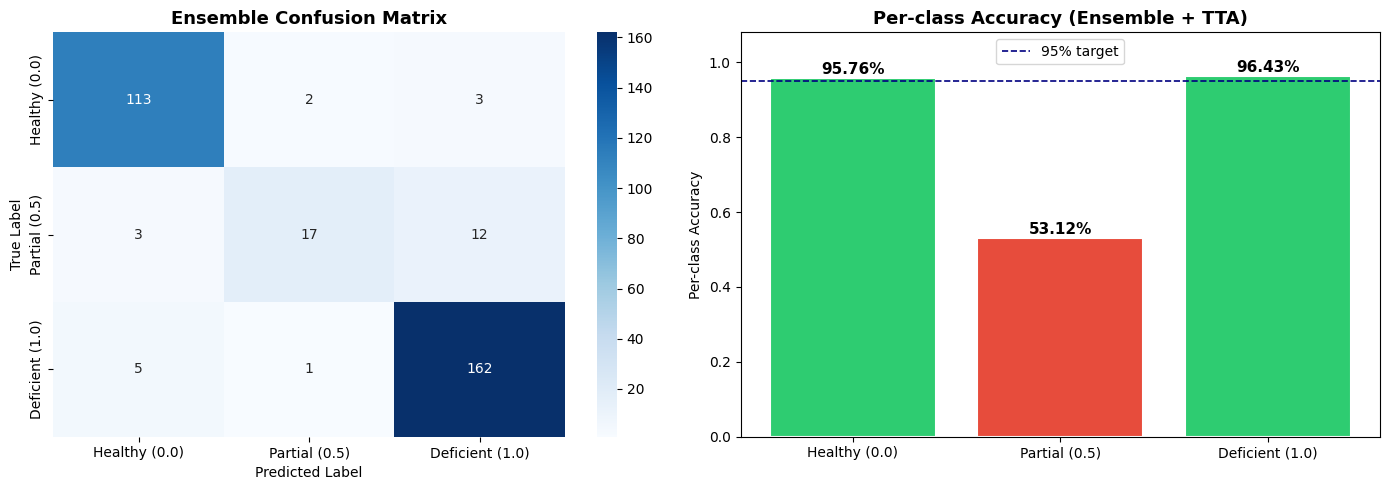

Plot saved.


In [17]:
# Cell 15: Confusion Matrix + Per-class Accuracy

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test_encoded, final_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=hyper_class_names,
    yticklabels=hyper_class_names,
    ax=axes[0]
)
axes[0].set_title('Ensemble Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors = ['#2ecc71' if a >= 0.9 else '#f39c12' if a >= 0.8 else '#e74c3c' for a in per_class_acc]
bars   = axes[1].bar(hyper_class_names, per_class_acc, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 1.08)
axes[1].set_ylabel('Per-class Accuracy')
axes[1].set_title('Per-class Accuracy (Ensemble + TTA)', fontsize=13, fontweight='bold')
axes[1].axhline(0.95, color='navy', linestyle='--', linewidth=1.2, label='95% target')
axes[1].legend()
for bar, acc in zip(bars, per_class_acc):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{acc:.2%}', ha='center', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('../models/final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [18]:
# Cell 16: Save All Models

for name, model in all_models.items():
    path = f'../models/{name}_final.h5'
    model.save(path)
    print(f'Saved: {path}')

print('\nAll models saved. Notebook 03 complete!')

Saved: ../models/ResNet50_final.h5


Saved: ../models/DenseNet121_final.h5
Saved: ../models/CustomCNN_final.h5

All models saved. Notebook 03 complete!


In [20]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — Imports & Style Setup
# ═══════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ── Global Plot Style ──
plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 9,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ── Color Palette ──
MODEL_COLORS = {
    'ResNet50'   : '#3498db',
    'DenseNet121': '#e74c3c',
    'CustomCNN'  : '#2ecc71',
    'Ensemble+TTA': '#9b59b6'
}
CLASS_COLORS = ['#1abc9c', '#e67e22', '#8e44ad']   # Healthy, Partial, Deficient
METRIC_COLORS = {'Precision': '#2980b9', 'Recall': '#e67e22', 'F1-Score': '#8e44ad'}

import os
SAVE_DIR = '../models/viz_outputs/'
os.makedirs(SAVE_DIR, exist_ok=True)

print('✅ Imports & style configured.')
print(f'📁 Plots will be saved to: {SAVE_DIR}')

✅ Imports & style configured.
📁 Plots will be saved to: ../models/viz_outputs/


In [21]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — Compute All Metrics (runs once, reused everywhere)
# ═══════════════════════════════════════════════════════════

# ── Per-model predictions ──
all_preds_dict = {}
all_probs_dict = {}

for name, model in all_models.items():
    probs = model.predict(X_test_hyper, verbose=0)
    all_probs_dict[name] = probs
    all_preds_dict[name] = np.argmax(probs, axis=1)

# Ensemble (TTA-weighted)
all_probs_dict['Ensemble+TTA'] = weighted_probs
all_preds_dict['Ensemble+TTA'] = final_preds

all_model_names = list(all_preds_dict.keys())   # [ResNet50, DenseNet121, CustomCNN, Ensemble+TTA]

# ── Per-model metrics ──
metrics_dict = {}   # {model_name: {Precision: [...], Recall: [...], F1: [...], Accuracy: float}}

for name, preds in all_preds_dict.items():
    p, r, f, _ = precision_recall_fscore_support(
        y_test_encoded, preds, average=None, zero_division=0
    )
    acc = accuracy_score(y_test_encoded, preds)
    metrics_dict[name] = {
        'Precision': p,
        'Recall'   : r,
        'F1-Score' : f,
        'Accuracy' : acc
    }

# ── Binarize labels for ROC ──
y_bin = label_binarize(y_test_encoded, classes=[0, 1, 2])   # (N, 3)

print('✅ All metrics computed.')
print(f'   Models   : {all_model_names}')
print(f'   Test set : {len(y_test_encoded)} samples')
print()
for name, m in metrics_dict.items():
    print(f'   {name:15s}  acc={m["Accuracy"]*100:.2f}%')

✅ All metrics computed.
   Models   : ['ResNet50', 'DenseNet121', 'CustomCNN', 'Ensemble+TTA']
   Test set : 318 samples

   ResNet50         acc=65.09%
   DenseNet121      acc=72.33%
   CustomCNN        acc=93.40%
   Ensemble+TTA     acc=91.82%


In [22]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 1 — Training & Validation Curves
# ═══════════════════════════════════════════════════════════
# NOTE: This uses 'histories' dict if it exists in memory.
# If not (notebook was run without saving histories), it
# loads from saved .npy history files or shows a clear message.

import os

def load_or_get_histories():
    """Try to get histories from memory, else load from disk."""
    # Case 1: histories already in memory (from modified Cell 9/10/11)
    if 'histories' in dir() or 'histories' in globals():
        return globals().get('histories', {})

    # Case 2: Try loading saved .npy history files
    hist_dict = {}
    for mname in ['ResNet50', 'DenseNet121', 'CustomCNN']:
        path = f'../models/{mname}_history.npy'
        if os.path.exists(path):
            hist_dict[mname] = type('H', (), {'history': np.load(path, allow_pickle=True).item()})()
    return hist_dict


histories_loaded = load_or_get_histories()

if histories_loaded:
    fig, axes = plt.subplots(2, len(histories_loaded), figsize=(6*len(histories_loaded), 10))
    if len(histories_loaded) == 1:
        axes = np.array(axes).reshape(2, 1)
    fig.suptitle('Training & Validation History — All Models', fontsize=16, fontweight='bold', y=1.01)

    for col, (name, hist) in enumerate(histories_loaded.items()):
        h      = hist.history
        epochs = range(1, len(h['accuracy']) + 1)
        color  = MODEL_COLORS.get(name, '#7f8c8d')

        # ── Accuracy ──
        ax = axes[0, col]
        ax.plot(epochs, h['accuracy'],     color=color, lw=2.5, label='Train Acc')
        ax.plot(epochs, h['val_accuracy'], color=color, lw=2.5, label='Val Acc', ls='--')
        ax.fill_between(epochs, h['accuracy'], h['val_accuracy'],
                        alpha=0.10, color=color, label='Overfit gap')
        ax.axhline(0.95, color='#2c3e50', ls=':', lw=1.2, alpha=0.7, label='95% target')
        best_val = max(h['val_accuracy'])
        best_ep  = h['val_accuracy'].index(best_val) + 1
        ax.axvline(best_ep, color=color, ls='-.', alpha=0.5)
        ax.annotate(f'Best: {best_val:.3f}\n(Ep {best_ep})',
                    xy=(best_ep, best_val), xytext=(best_ep+1, best_val-0.05),
                    fontsize=8, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color))
        ax.set_title(f'{name} — Accuracy', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.25)

        # ── Loss ──
        ax2 = axes[1, col]
        ax2.plot(epochs, h['loss'],     color=color, lw=2.5, label='Train Loss')
        ax2.plot(epochs, h['val_loss'], color=color, lw=2.5, label='Val Loss', ls='--')
        ax2.fill_between(epochs, h['loss'], h['val_loss'], alpha=0.10, color=color)
        ax2.set_title(f'{name} — Loss', fontweight='bold')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Focal Loss')
        ax2.legend(); ax2.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}viz1_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: viz1_training_curves.png')

else:
    print('⚠️  Training history not found in memory or on disk.')
    print('   To enable this plot, add this to Cell 9 before .fit():')  
    print()  
    print("   histories = {}")
    print("   h = resnet_model.fit(...)")
    print("   histories['ResNet50'] = h")
    print()
    print('   Skipping Viz 1. All other visualizations will still work.')

⚠️  Training history not found in memory or on disk.
   To enable this plot, add this to Cell 9 before .fit():

   histories = {}
   h = resnet_model.fit(...)
   histories['ResNet50'] = h

   Skipping Viz 1. All other visualizations will still work.


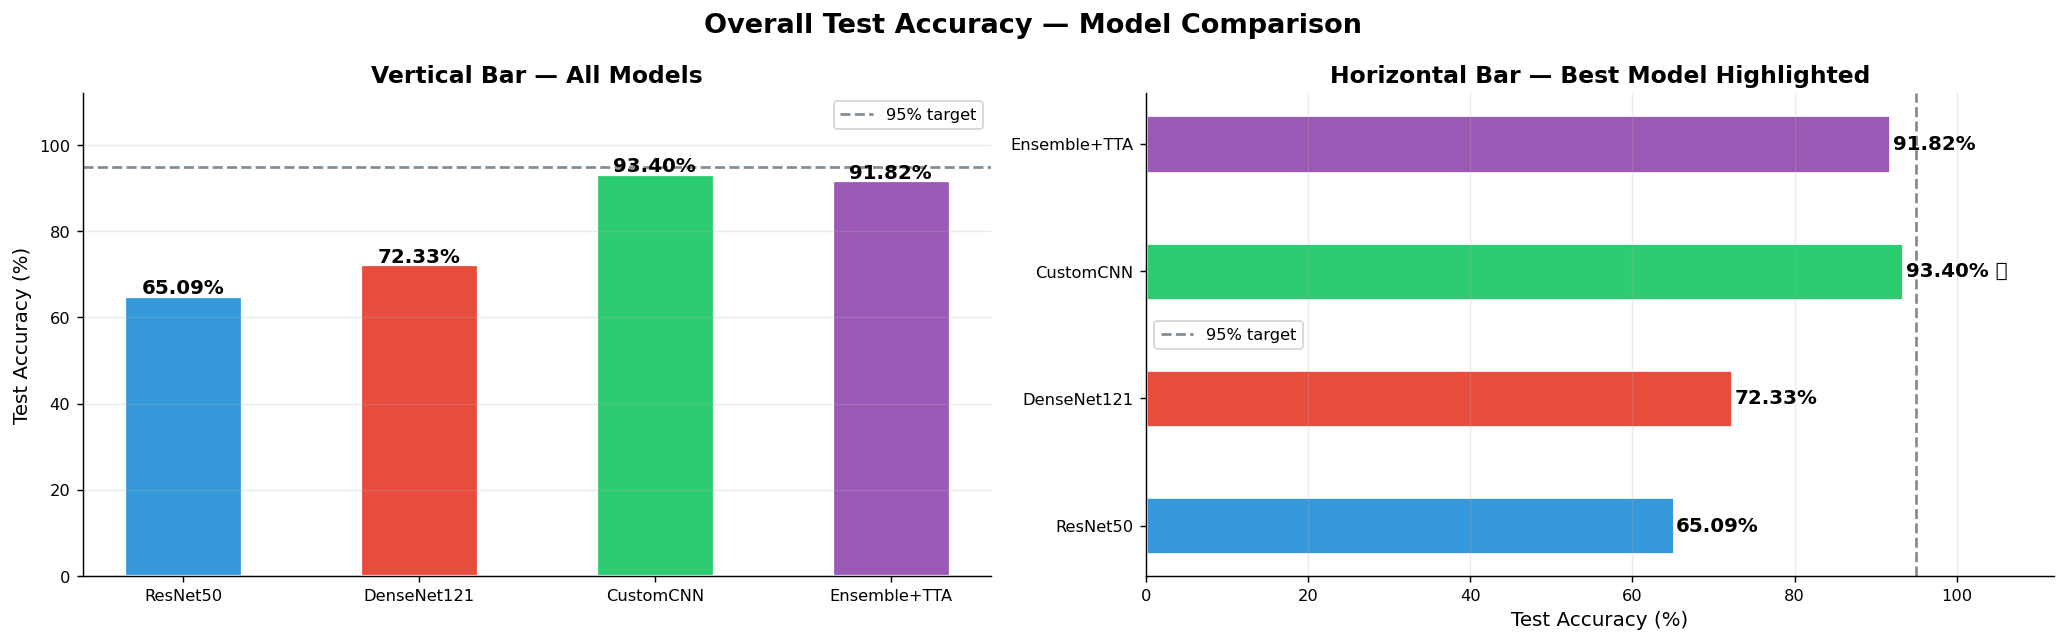

✅ Saved: viz2_accuracy_comparison.png


In [23]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 2 — Overall Accuracy Comparison (Bar Chart)
# ═══════════════════════════════════════════════════════════

names_viz  = all_model_names
accs_viz   = [metrics_dict[n]['Accuracy'] * 100 for n in names_viz]
colors_viz = [MODEL_COLORS.get(n, '#95a5a6') for n in names_viz]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Overall Test Accuracy — Model Comparison', fontsize=15, fontweight='bold')

# ── Vertical Bar ──
bars = axes[0].bar(names_viz, accs_viz, color=colors_viz, edgecolor='white',
                   linewidth=1.8, width=0.5)
for bar, val in zip(bars, accs_viz):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(95, color='#2c3e50', ls='--', lw=1.5, alpha=0.6, label='95% target')
axes[0].set_ylim(0, 112)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Vertical Bar — All Models', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.25)

# ── Horizontal Bar with delta from best ──
best_acc = max(accs_viz)
deltas   = [v - min(accs_viz) for v in accs_viz]
bars2 = axes[1].barh(names_viz, accs_viz, color=colors_viz, edgecolor='white',
                     linewidth=1.5, height=0.45)
for bar, val, nm in zip(bars2, accs_viz, names_viz):
    star = ' ⭐' if val == best_acc else ''
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%{star}', va='center', fontsize=11, fontweight='bold')
axes[1].axvline(95, color='#2c3e50', ls='--', lw=1.5, alpha=0.6, label='95% target')
axes[1].set_xlim(0, 112)
axes[1].set_xlabel('Test Accuracy (%)')
axes[1].set_title('Horizontal Bar — Best Model Highlighted', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}viz2_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: viz2_accuracy_comparison.png')

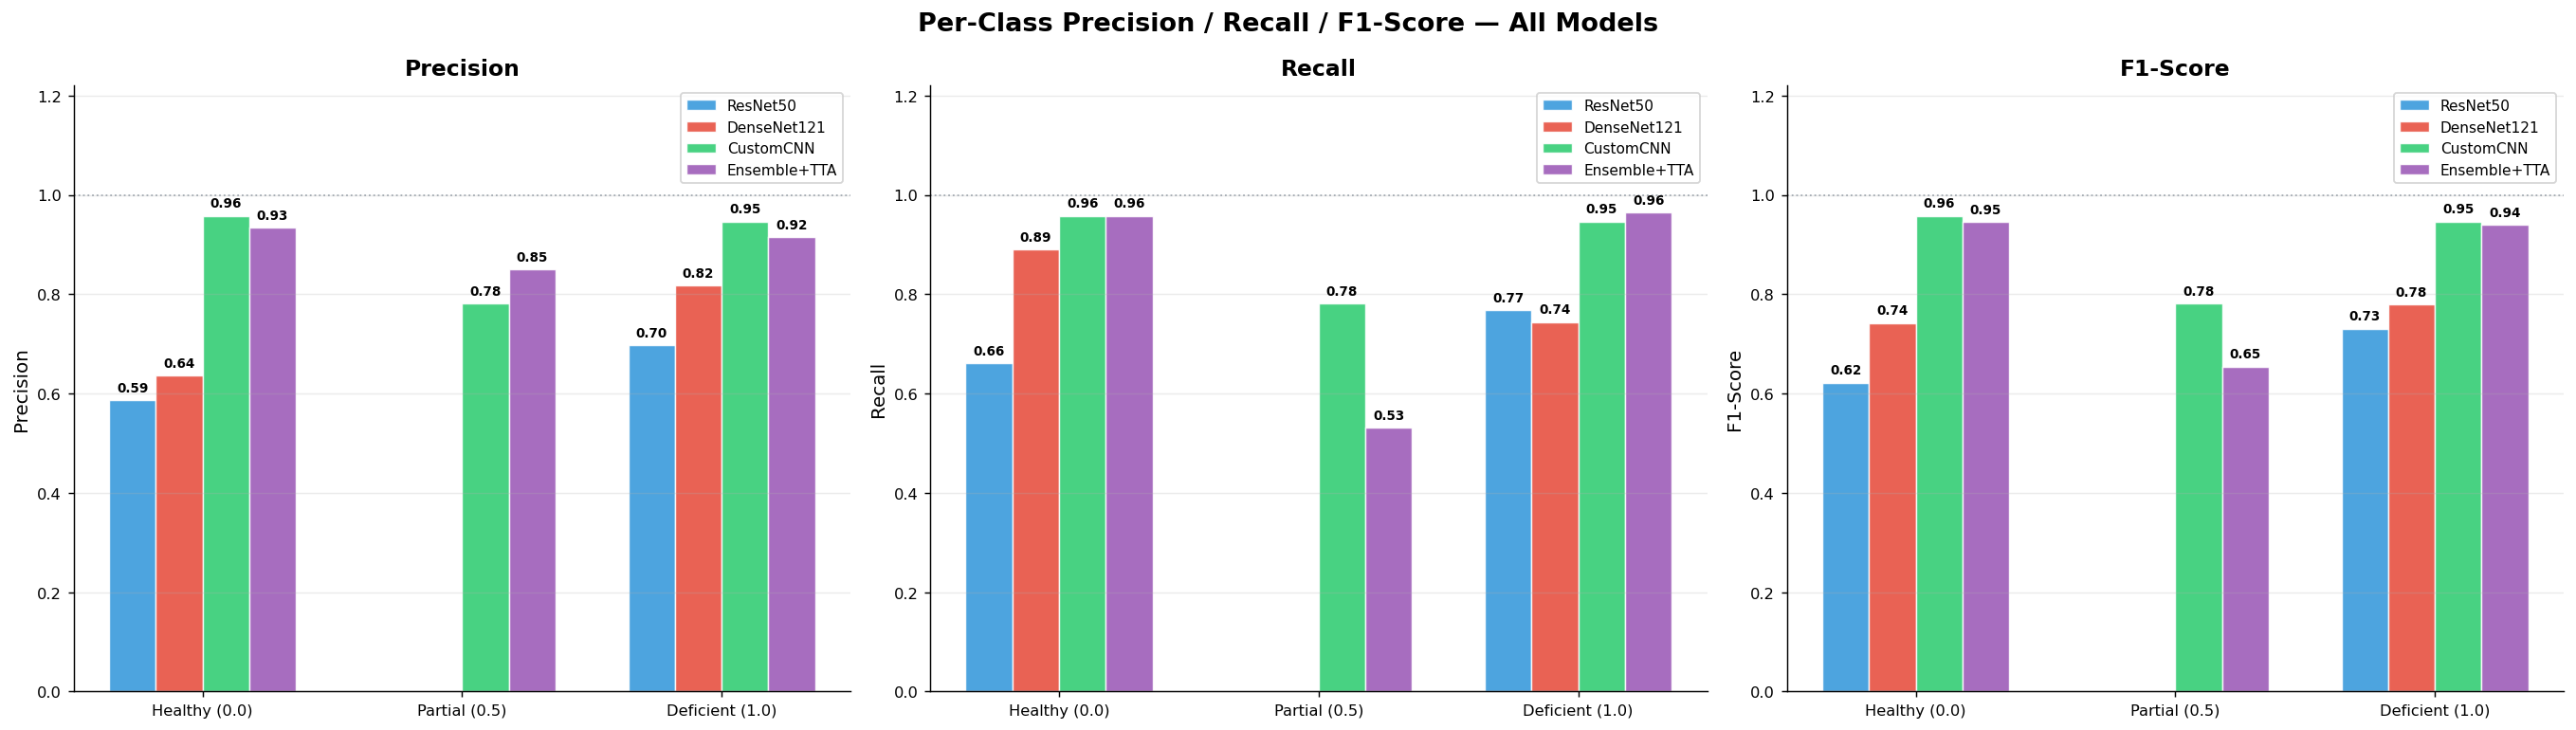

✅ Saved: viz3_precision_recall_f1.png


In [24]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 3 — Per-Class Precision / Recall / F1-Score
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Per-Class Precision / Recall / F1-Score — All Models',
             fontsize=15, fontweight='bold')

x      = np.arange(len(hyper_class_names))
width  = 0.18
n_mdls = len(all_model_names)

for ax, metric in zip(axes, ['Precision', 'Recall', 'F1-Score']):
    for i, (mname, color) in enumerate(zip(all_model_names, MODEL_COLORS.values())):
        vals   = metrics_dict[mname][metric]
        offset = (i - n_mdls/2 + 0.5) * width
        bars   = ax.bar(x + offset, vals, width, label=mname,
                        color=color, alpha=0.88, edgecolor='white', linewidth=0.8)
        for bar, v in zip(bars, vals):
            if v > 0.05:   # Only annotate visible bars
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.012,
                        f'{v:.2f}', ha='center', va='bottom',
                        fontsize=7.5, fontweight='bold')

    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(hyper_class_names, fontsize=9)
    ax.set_ylim(0, 1.22)
    ax.set_ylabel(metric)
    ax.axhline(1.0, color='#2c3e50', ls=':', lw=1, alpha=0.4)
    ax.legend(fontsize=8.5); ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}viz3_precision_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: viz3_precision_recall_f1.png')

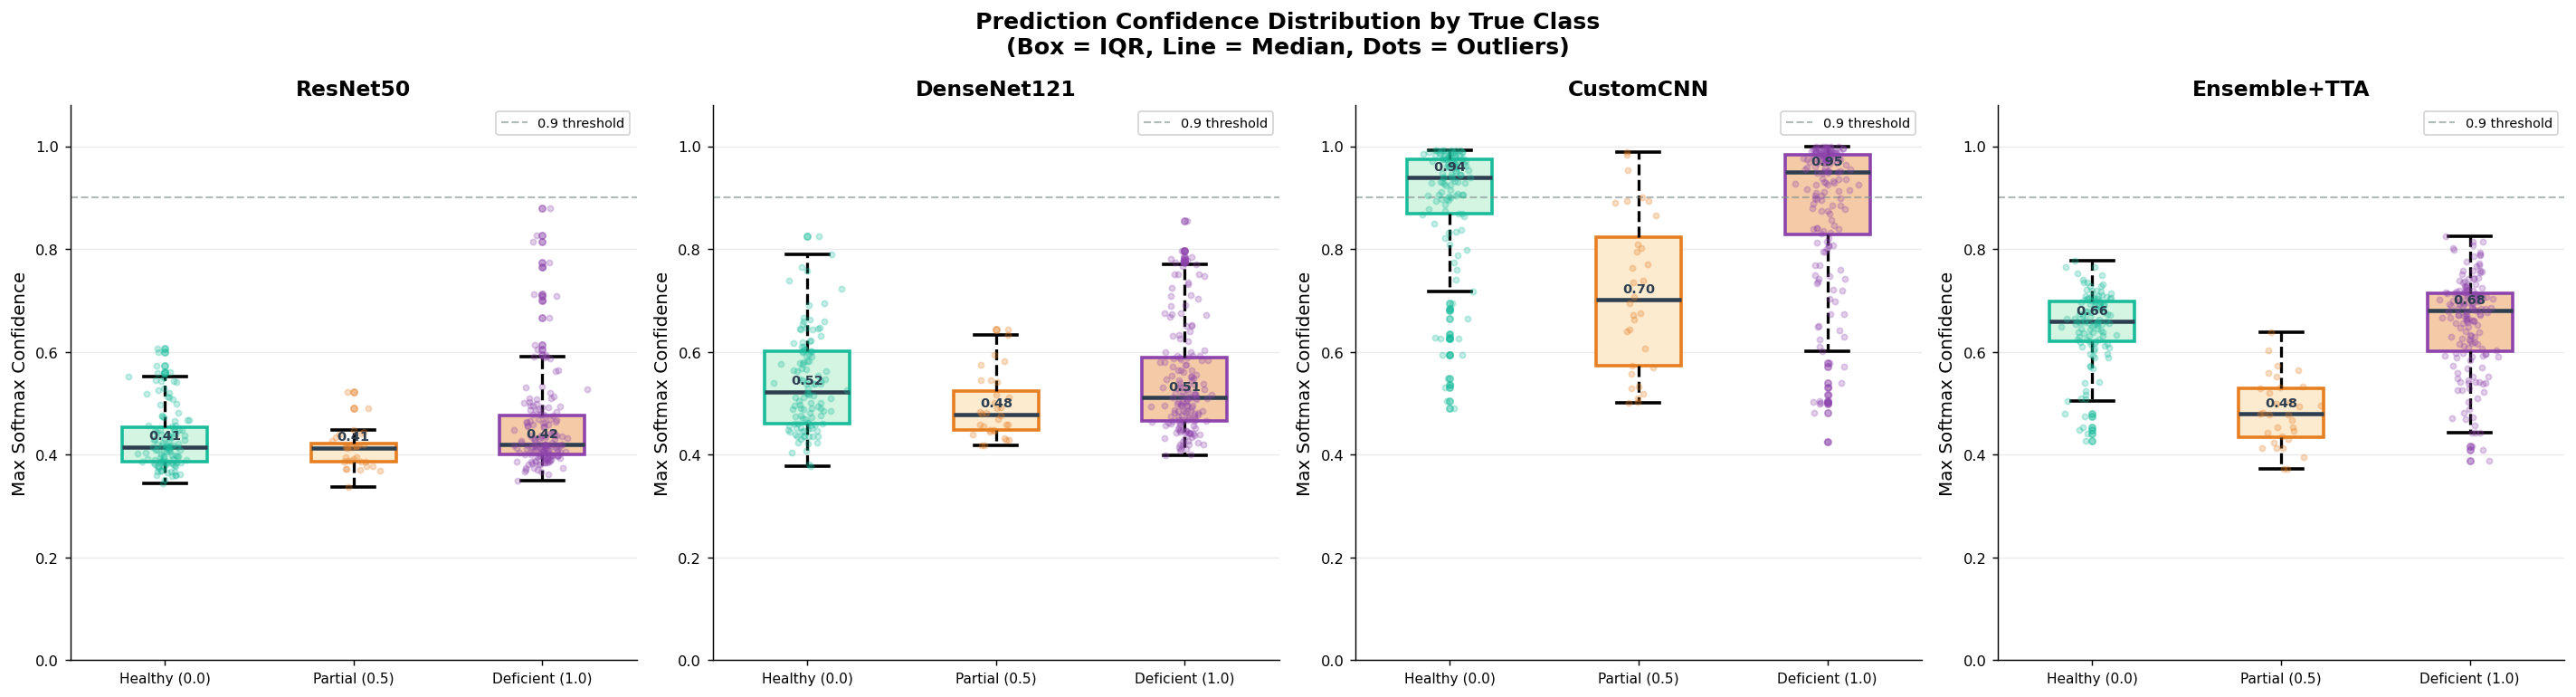

✅ Saved: viz4_confidence_boxplots.png


In [25]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 4 — Prediction Confidence Box Plots
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Prediction Confidence Distribution by True Class\n'
             '(Box = IQR, Line = Median, Dots = Outliers)',
             fontsize=14, fontweight='bold')

box_fill_colors = ['#d5f5e3', '#fdebd0', '#f5cba7']   # light green, orange, red
box_edge_colors = ['#1abc9c', '#e67e22', '#8e44ad']

for ax, mname in zip(axes, all_model_names):
    probs = all_probs_dict[mname]
    max_conf = np.max(probs, axis=1)   # Highest softmax probability per sample

    data = [max_conf[y_test_encoded == c] for c in range(len(hyper_class_names))]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color='#2c3e50', linewidth=2.5),
        whiskerprops=dict(linewidth=1.8, linestyle='--'),
        capprops=dict(linewidth=2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none')
    )
    for patch, fcolor, ecolor in zip(bp['boxes'], box_fill_colors, box_edge_colors):
        patch.set_facecolor(fcolor)
        patch.set_edgecolor(ecolor)
        patch.set_linewidth(2)
    for flier, ecolor in zip(bp['fliers'], box_edge_colors):
        flier.set_markerfacecolor(ecolor)
        flier.set_markeredgecolor(ecolor)

    # Overlay individual points (swarm-style for small datasets)
    for j, (d, ecolor) in enumerate(zip(data, box_edge_colors)):
        jitter = np.random.normal(0, 0.06, len(d))
        ax.scatter(np.full(len(d), j+1) + jitter, d,
                   color=ecolor, alpha=0.25, s=12, zorder=3)

    # Annotate medians
    for j, d in enumerate(data):
        med = np.median(d)
        ax.text(j+1, med + 0.015, f'{med:.2f}',
                ha='center', fontsize=8, fontweight='bold', color='#2c3e50')

    ax.set_xticklabels(hyper_class_names, fontsize=8.5)
    ax.set_title(f'{mname}', fontweight='bold')
    ax.set_ylabel('Max Softmax Confidence')
    ax.set_ylim(0, 1.08)
    ax.axhline(0.9, color='#7f8c8d', ls='--', lw=1.2, alpha=0.6, label='0.9 threshold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}viz4_confidence_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: viz4_confidence_boxplots.png')

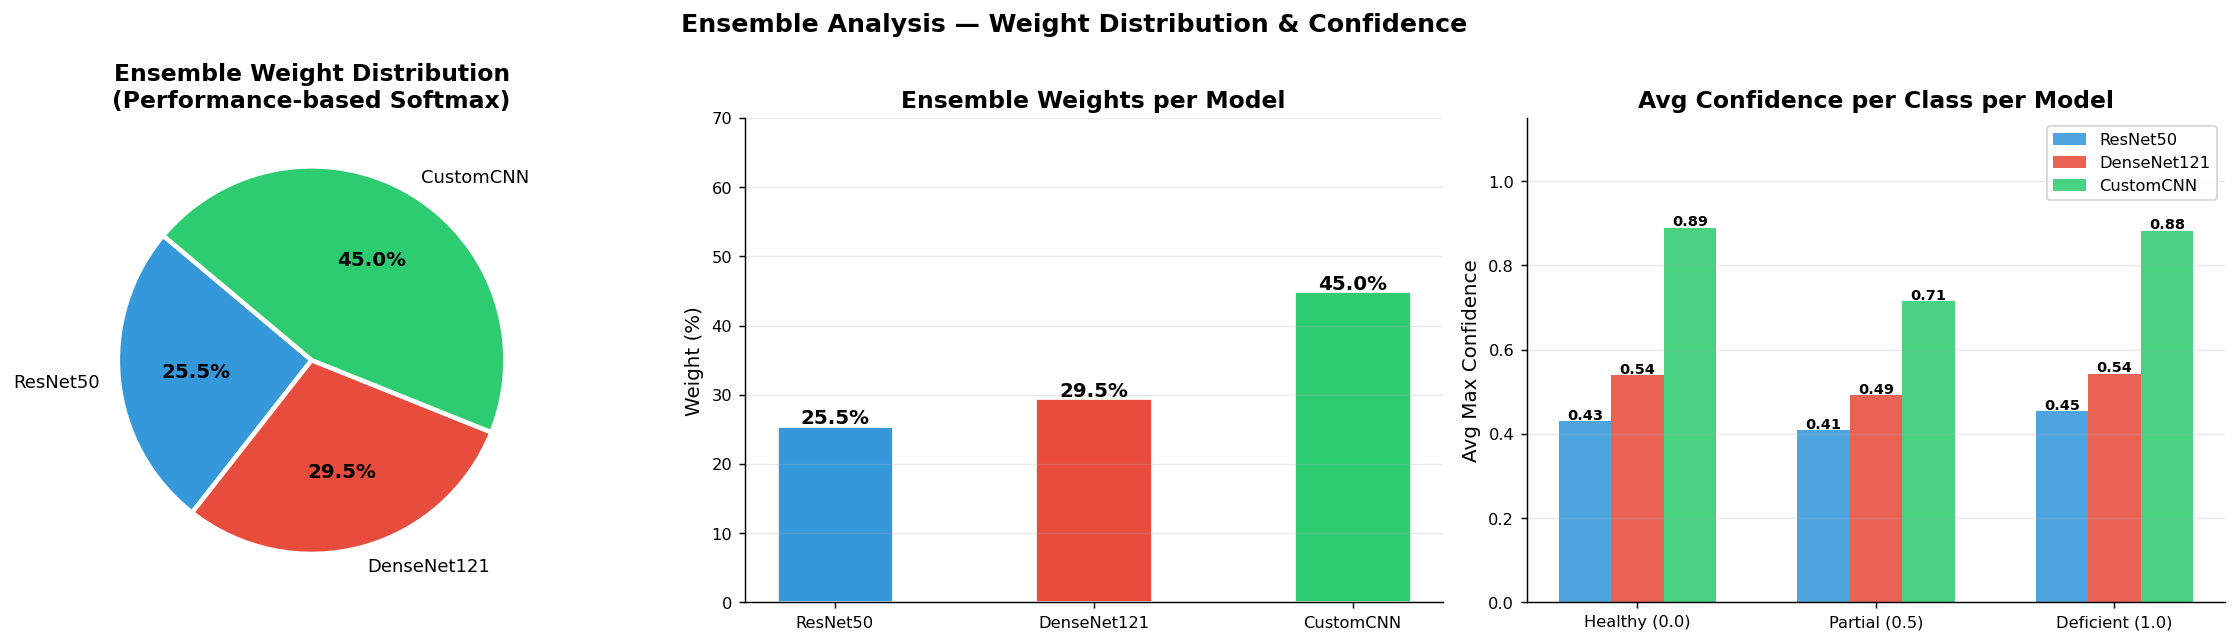

✅ Saved: viz5_ensemble_weights.png


In [26]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 5 — Ensemble Weight Distribution
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ensemble Analysis — Weight Distribution & Confidence', fontsize=14, fontweight='bold')

pie_colors = [MODEL_COLORS[n] for n in model_names]

# ── Pie chart ──
wedges, texts, autotexts = axes[0].pie(
    ens_weights, labels=model_names, colors=pie_colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
axes[0].set_title('Ensemble Weight Distribution\n(Performance-based Softmax)', fontweight='bold')

# ── Bar chart of weights ──
bar_w = axes[1].bar(model_names, ens_weights * 100, color=pie_colors,
                    edgecolor='white', linewidth=1.5, width=0.45)
for bar, w in zip(bar_w, ens_weights):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{w*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 70)
axes[1].set_ylabel('Weight (%)')
axes[1].set_title('Ensemble Weights per Model', fontweight='bold')
axes[1].grid(axis='y', alpha=0.25)

# ── Avg max confidence per class per model ──
x_ens = np.arange(len(hyper_class_names))
w_ens = 0.22
for i, (mname, color) in enumerate(zip(model_names, pie_colors)):
    probs = all_probs_dict[mname]
    avg   = [np.mean(np.max(probs[y_test_encoded == c], axis=1))
             for c in range(len(hyper_class_names))]
    offset = (i - len(model_names)/2 + 0.5) * w_ens
    bars_c = axes[2].bar(x_ens + offset, avg, w_ens, label=mname, color=color, alpha=0.88)
    for bar, v in zip(bars_c, avg):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')
axes[2].set_xticks(x_ens)
axes[2].set_xticklabels(hyper_class_names)
axes[2].set_ylim(0, 1.15)
axes[2].set_ylabel('Avg Max Confidence')
axes[2].set_title('Avg Confidence per Class per Model', fontweight='bold')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}viz5_ensemble_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: viz5_ensemble_weights.png')

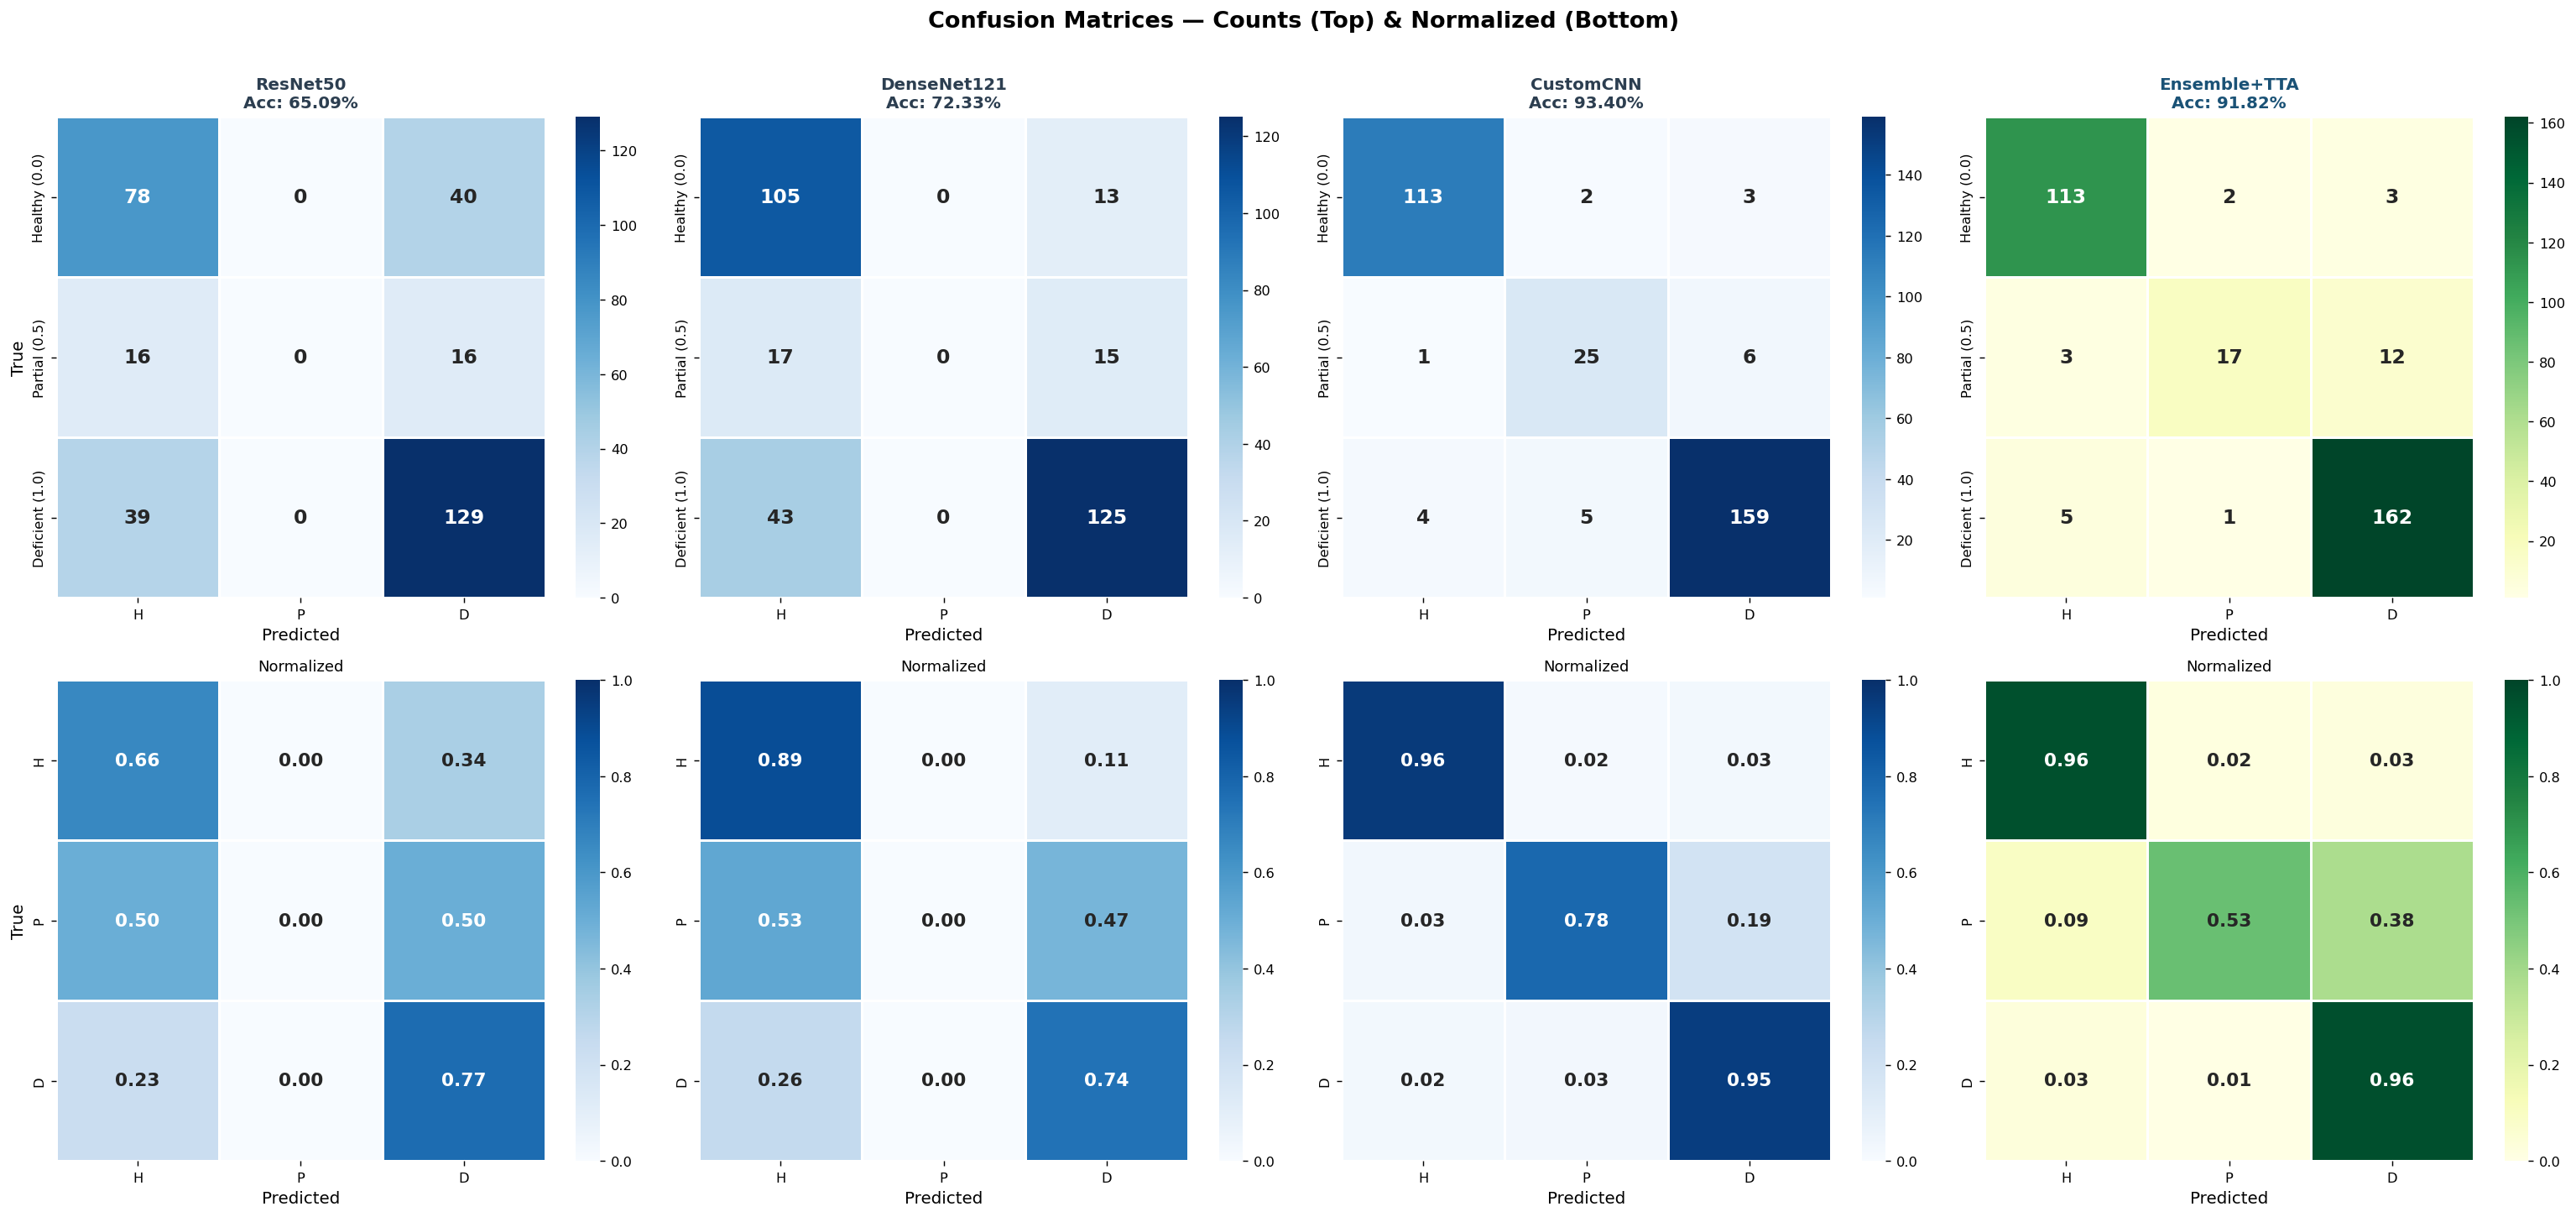

✅ Saved: viz6_confusion_matrices.png


In [27]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 6 — Confusion Matrices (All Models + Ensemble)
# ═══════════════════════════════════════════════════════════

n_models = len(all_model_names)
fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 11))
fig.suptitle('Confusion Matrices — Counts (Top) & Normalized (Bottom)',
             fontsize=15, fontweight='bold', y=1.01)

short_names = ['H', 'P', 'D']   # Healthy, Partial, Deficient

for col, mname in enumerate(all_model_names):
    preds = all_preds_dict[mname]
    cm    = confusion_matrix(y_test_encoded, preds)
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    cmap  = 'YlGn' if mname == 'Ensemble+TTA' else 'Blues'

    # ── Raw counts ──
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=short_names, yticklabels=hyper_class_names,
        ax=axes[0, col], linewidths=0.8, linecolor='white',
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    acc = metrics_dict[mname]['Accuracy']
    axes[0, col].set_title(
        f'{mname}\nAcc: {acc*100:.2f}%',
        fontweight='bold', fontsize=11,
        color='#1a5276' if mname == 'Ensemble+TTA' else '#2c3e50'
    )
    axes[0, col].set_xlabel('Predicted')
    axes[0, col].set_ylabel('True' if col == 0 else '')

    # ── Normalized ──
    sns.heatmap(
        cm_n, annot=True, fmt='.2f', cmap=cmap,
        xticklabels=short_names, yticklabels=short_names,
        ax=axes[1, col], vmin=0, vmax=1,
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    axes[1, col].set_title('Normalized', fontsize=10)
    axes[1, col].set_xlabel('Predicted')
    axes[1, col].set_ylabel('True' if col == 0 else '')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}viz6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: viz6_confusion_matrices.png')

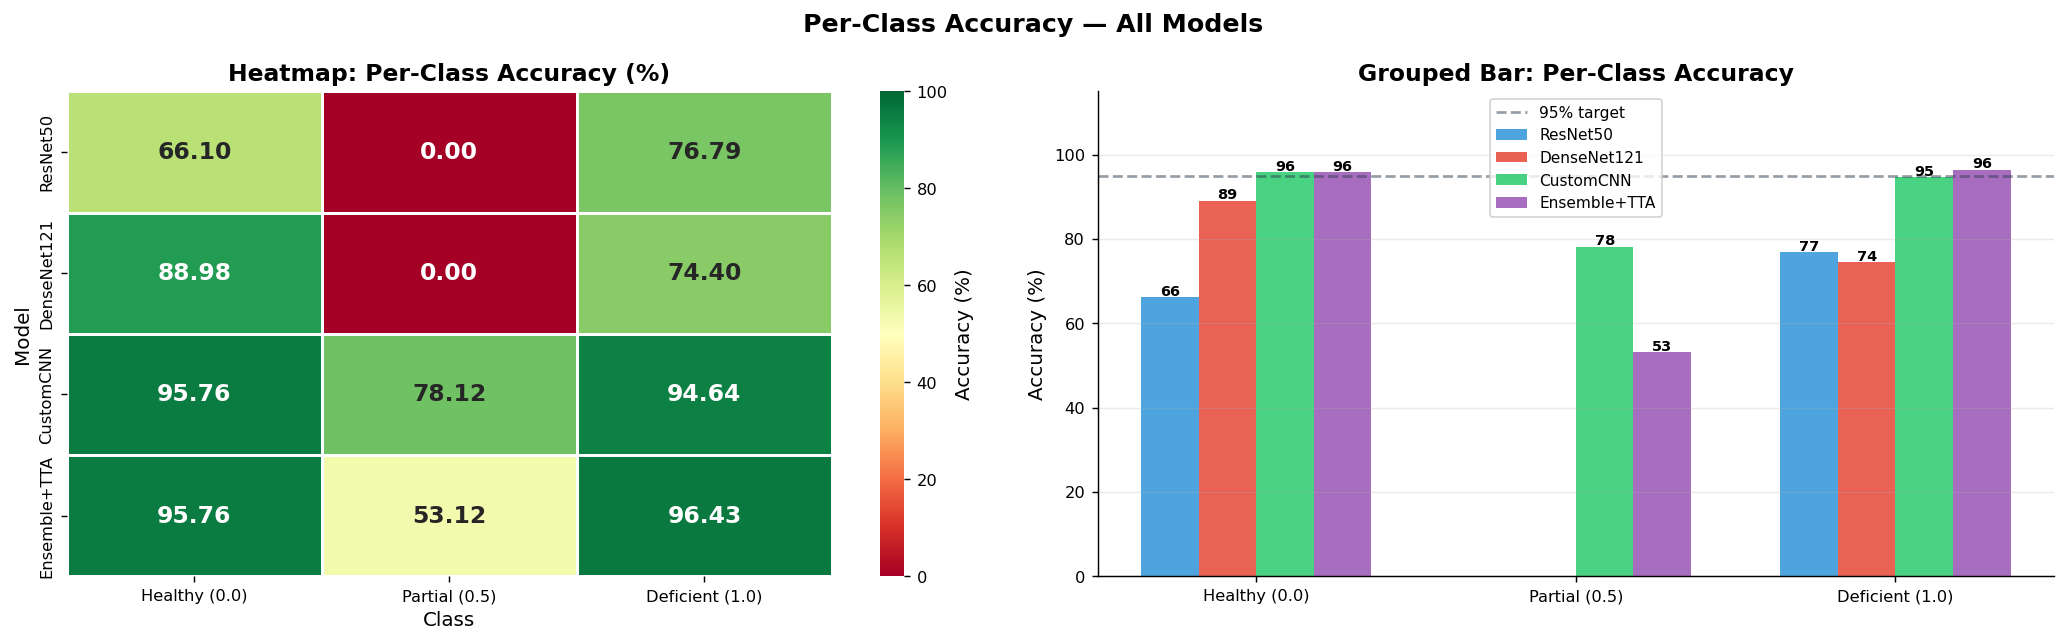

✅ Saved: viz7_per_class_accuracy_heatmap.png


In [28]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 7 — Per-Class Accuracy Heatmap (All Models)
# ═══════════════════════════════════════════════════════════

# Build matrix: rows=models, cols=classes
per_class_acc_matrix = []
for mname in all_model_names:
    cm    = confusion_matrix(y_test_encoded, all_preds_dict[mname])
    pc    = cm.diagonal() / cm.sum(axis=1)
    per_class_acc_matrix.append(pc)

pc_df = pd.DataFrame(
    np.array(per_class_acc_matrix) * 100,
    index=all_model_names,
    columns=hyper_class_names
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Class Accuracy — All Models', fontsize=14, fontweight='bold')

# ── Heatmap ──
sns.heatmap(
    pc_df, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=100, ax=axes[0],
    linewidths=0.8, linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'label': 'Accuracy (%)'}
)
axes[0].set_title('Heatmap: Per-Class Accuracy (%)', fontweight='bold')
axes[0].set_ylabel('Model')
axes[0].set_xlabel('Class')

# ── Grouped bar ──
x_pc   = np.arange(len(hyper_class_names))
w_pc   = 0.18
for i, (mname, color) in enumerate(zip(all_model_names, MODEL_COLORS.values())):
    vals   = pc_df.loc[mname].values
    offset = (i - len(all_model_names)/2 + 0.5) * w_pc
    bars_p = axes[1].bar(x_pc + offset, vals, w_pc, label=mname, color=color, alpha=0.88)
    for bar, v in zip(bars_p, vals):
        if v > 5:
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                         f'{v:.0f}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_xticks(x_pc)
axes[1].set_xticklabels(hyper_class_names)
axes[1].set_ylim(0, 115)
axes[1].axhline(95, color='#2c3e50', ls='--', lw=1.5, alpha=0.5, label='95% target')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Grouped Bar: Per-Class Accuracy', fontweight='bold')
axes[1].legend(fontsize=8.5); axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}viz7_per_class_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: viz7_per_class_accuracy_heatmap.png')

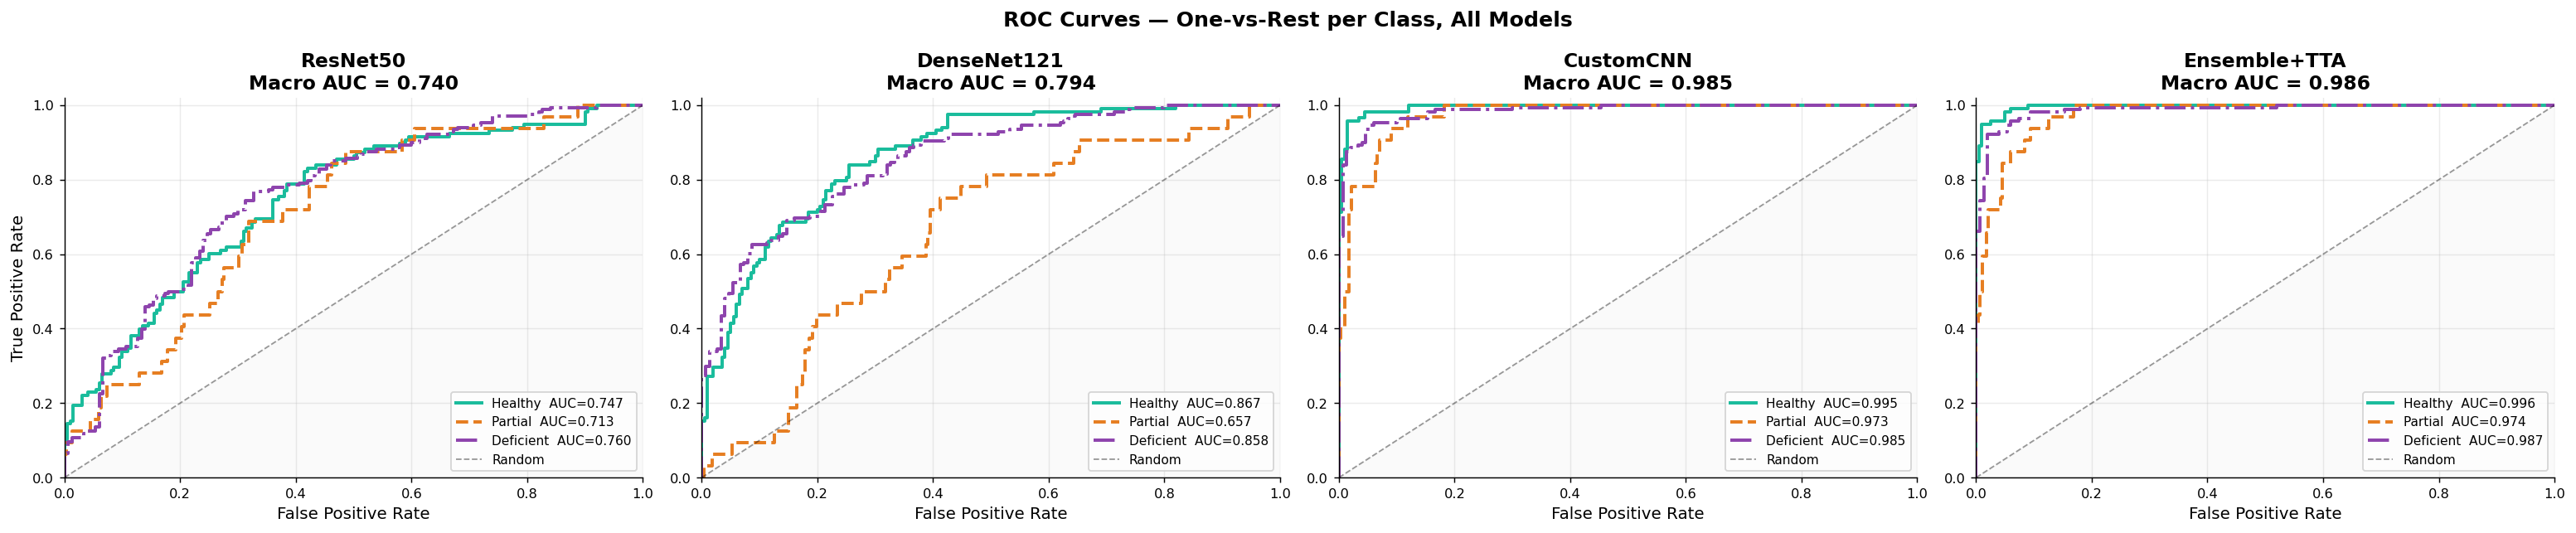

✅ Saved: viz8_roc_curves.png


In [29]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 8 — ROC Curves (One-vs-Rest, All Models)
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, len(all_model_names), figsize=(6*len(all_model_names), 5))
fig.suptitle('ROC Curves — One-vs-Rest per Class, All Models',
             fontsize=14, fontweight='bold')

line_styles = ['-', '--', '-.']

for ax, mname in zip(axes, all_model_names):
    probs = all_probs_dict[mname]
    auc_scores = []

    for c_idx, (c_name, c_color, ls) in enumerate(
            zip(hyper_class_names, CLASS_COLORS, line_styles)):
        fpr, tpr, _ = roc_curve(y_bin[:, c_idx], probs[:, c_idx])
        roc_auc      = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, color=c_color, lw=2.2, ls=ls,
                label=f'{c_name.split(" ")[0]}  AUC={roc_auc:.3f}')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random')
    ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
    ax.set_title(f'{mname}\nMacro AUC = {np.mean(auc_scores):.3f}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate' if mname == all_model_names[0] else '')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(loc='lower right', fontsize=8.5)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}viz8_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: viz8_roc_curves.png')

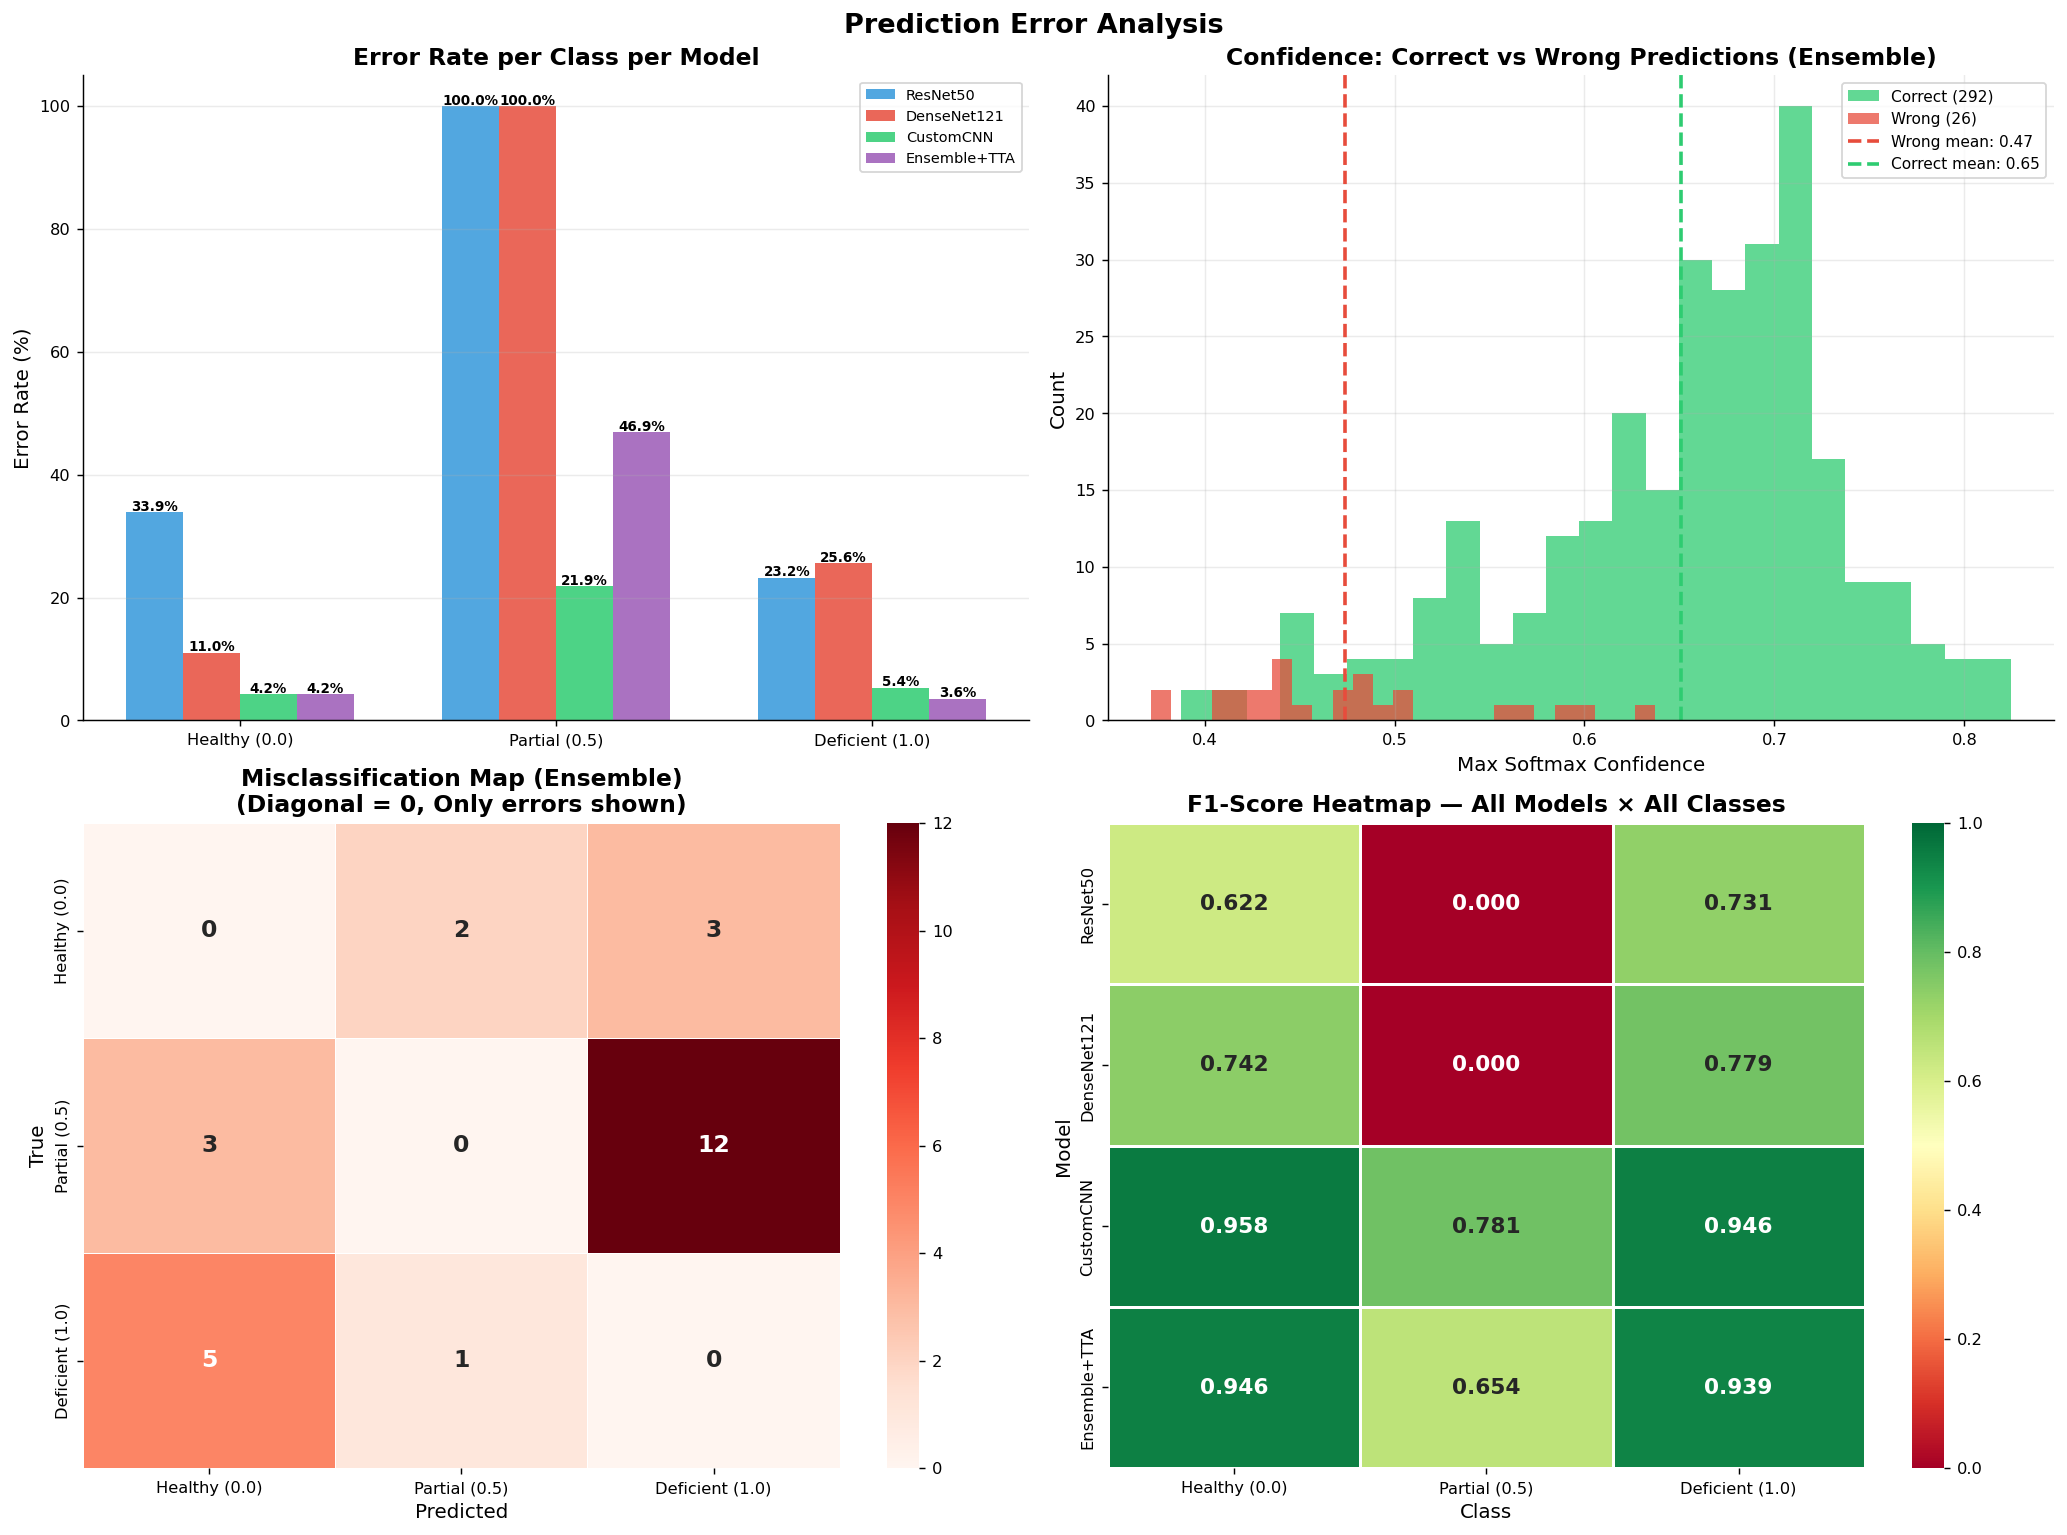

✅ Saved: viz9_error_analysis.png


In [30]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 9 — Error Analysis
# (Where does each model fail? What confidence do wrong predictions have?)
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Prediction Error Analysis', fontsize=15, fontweight='bold')

# ── Panel 1: Error rate per class per model ──
ax1 = axes[0, 0]
error_rates = {}
for mname in all_model_names:
    preds = all_preds_dict[mname]
    er    = []
    for c in range(len(hyper_class_names)):
        mask = y_test_encoded == c
        er.append(np.mean(preds[mask] != y_test_encoded[mask]) * 100)
    error_rates[mname] = er

x_err = np.arange(len(hyper_class_names))
w_err = 0.18
for i, (mname, color) in enumerate(zip(all_model_names, MODEL_COLORS.values())):
    offset = (i - len(all_model_names)/2 + 0.5) * w_err
    bars_e = ax1.bar(x_err + offset, error_rates[mname], w_err,
                     label=mname, color=color, alpha=0.85)
    for bar, v in zip(bars_e, error_rates[mname]):
        if v > 1:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{v:.1f}%', ha='center', fontsize=7.5, fontweight='bold')
ax1.set_xticks(x_err)
ax1.set_xticklabels(hyper_class_names)
ax1.set_ylabel('Error Rate (%)')
ax1.set_title('Error Rate per Class per Model', fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.25)

# ── Panel 2: Confidence of WRONG predictions (Ensemble) ──
ax2 = axes[0, 1]
wrong_mask = final_preds != y_test_encoded
if wrong_mask.sum() > 0:
    wrong_conf   = np.max(weighted_probs[wrong_mask], axis=1)
    correct_conf = np.max(weighted_probs[~wrong_mask], axis=1)
    ax2.hist(correct_conf, bins=25, color='#2ecc71', alpha=0.75, label=f'Correct ({(~wrong_mask).sum()})')
    ax2.hist(wrong_conf,   bins=25, color='#e74c3c', alpha=0.75, label=f'Wrong ({wrong_mask.sum()})')
    ax2.axvline(np.mean(wrong_conf),   color='#e74c3c', ls='--', lw=2,
                label=f'Wrong mean: {np.mean(wrong_conf):.2f}')
    ax2.axvline(np.mean(correct_conf), color='#2ecc71', ls='--', lw=2,
                label=f'Correct mean: {np.mean(correct_conf):.2f}')
else:
    ax2.text(0.5, 0.5, 'No wrong predictions!\nPerfect accuracy!',
             ha='center', va='center', transform=ax2.transAxes, fontsize=14,
             color='#2ecc71', fontweight='bold')
ax2.set_xlabel('Max Softmax Confidence')
ax2.set_ylabel('Count')
ax2.set_title('Confidence: Correct vs Wrong Predictions (Ensemble)', fontweight='bold')
ax2.legend(fontsize=8.5); ax2.grid(alpha=0.25)

# ── Panel 3: Misclassification direction heatmap (Ensemble) ──
ax3 = axes[1, 0]
cm_ens = confusion_matrix(y_test_encoded, final_preds)
np.fill_diagonal(cm_ens, 0)   # Zero diagonal = show only errors
sns.heatmap(
    cm_ens, annot=True, fmt='d', cmap='Reds',
    xticklabels=hyper_class_names, yticklabels=hyper_class_names,
    ax=ax3, linewidths=0.5, linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'}
)
ax3.set_title('Misclassification Map (Ensemble)\n(Diagonal = 0, Only errors shown)',
              fontweight='bold')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')

# ── Panel 4: F1 score summary table heatmap ──
ax4 = axes[1, 1]
f1_matrix = pd.DataFrame(
    {mname: metrics_dict[mname]['F1-Score'] for mname in all_model_names},
    index=hyper_class_names
).T
sns.heatmap(
    f1_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0, vmax=1, ax=ax4, linewidths=0.8, linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'}
)
ax4.set_title('F1-Score Heatmap — All Models × All Classes', fontweight='bold')
ax4.set_ylabel('Model'); ax4.set_xlabel('Class')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}viz9_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: viz9_error_analysis.png')

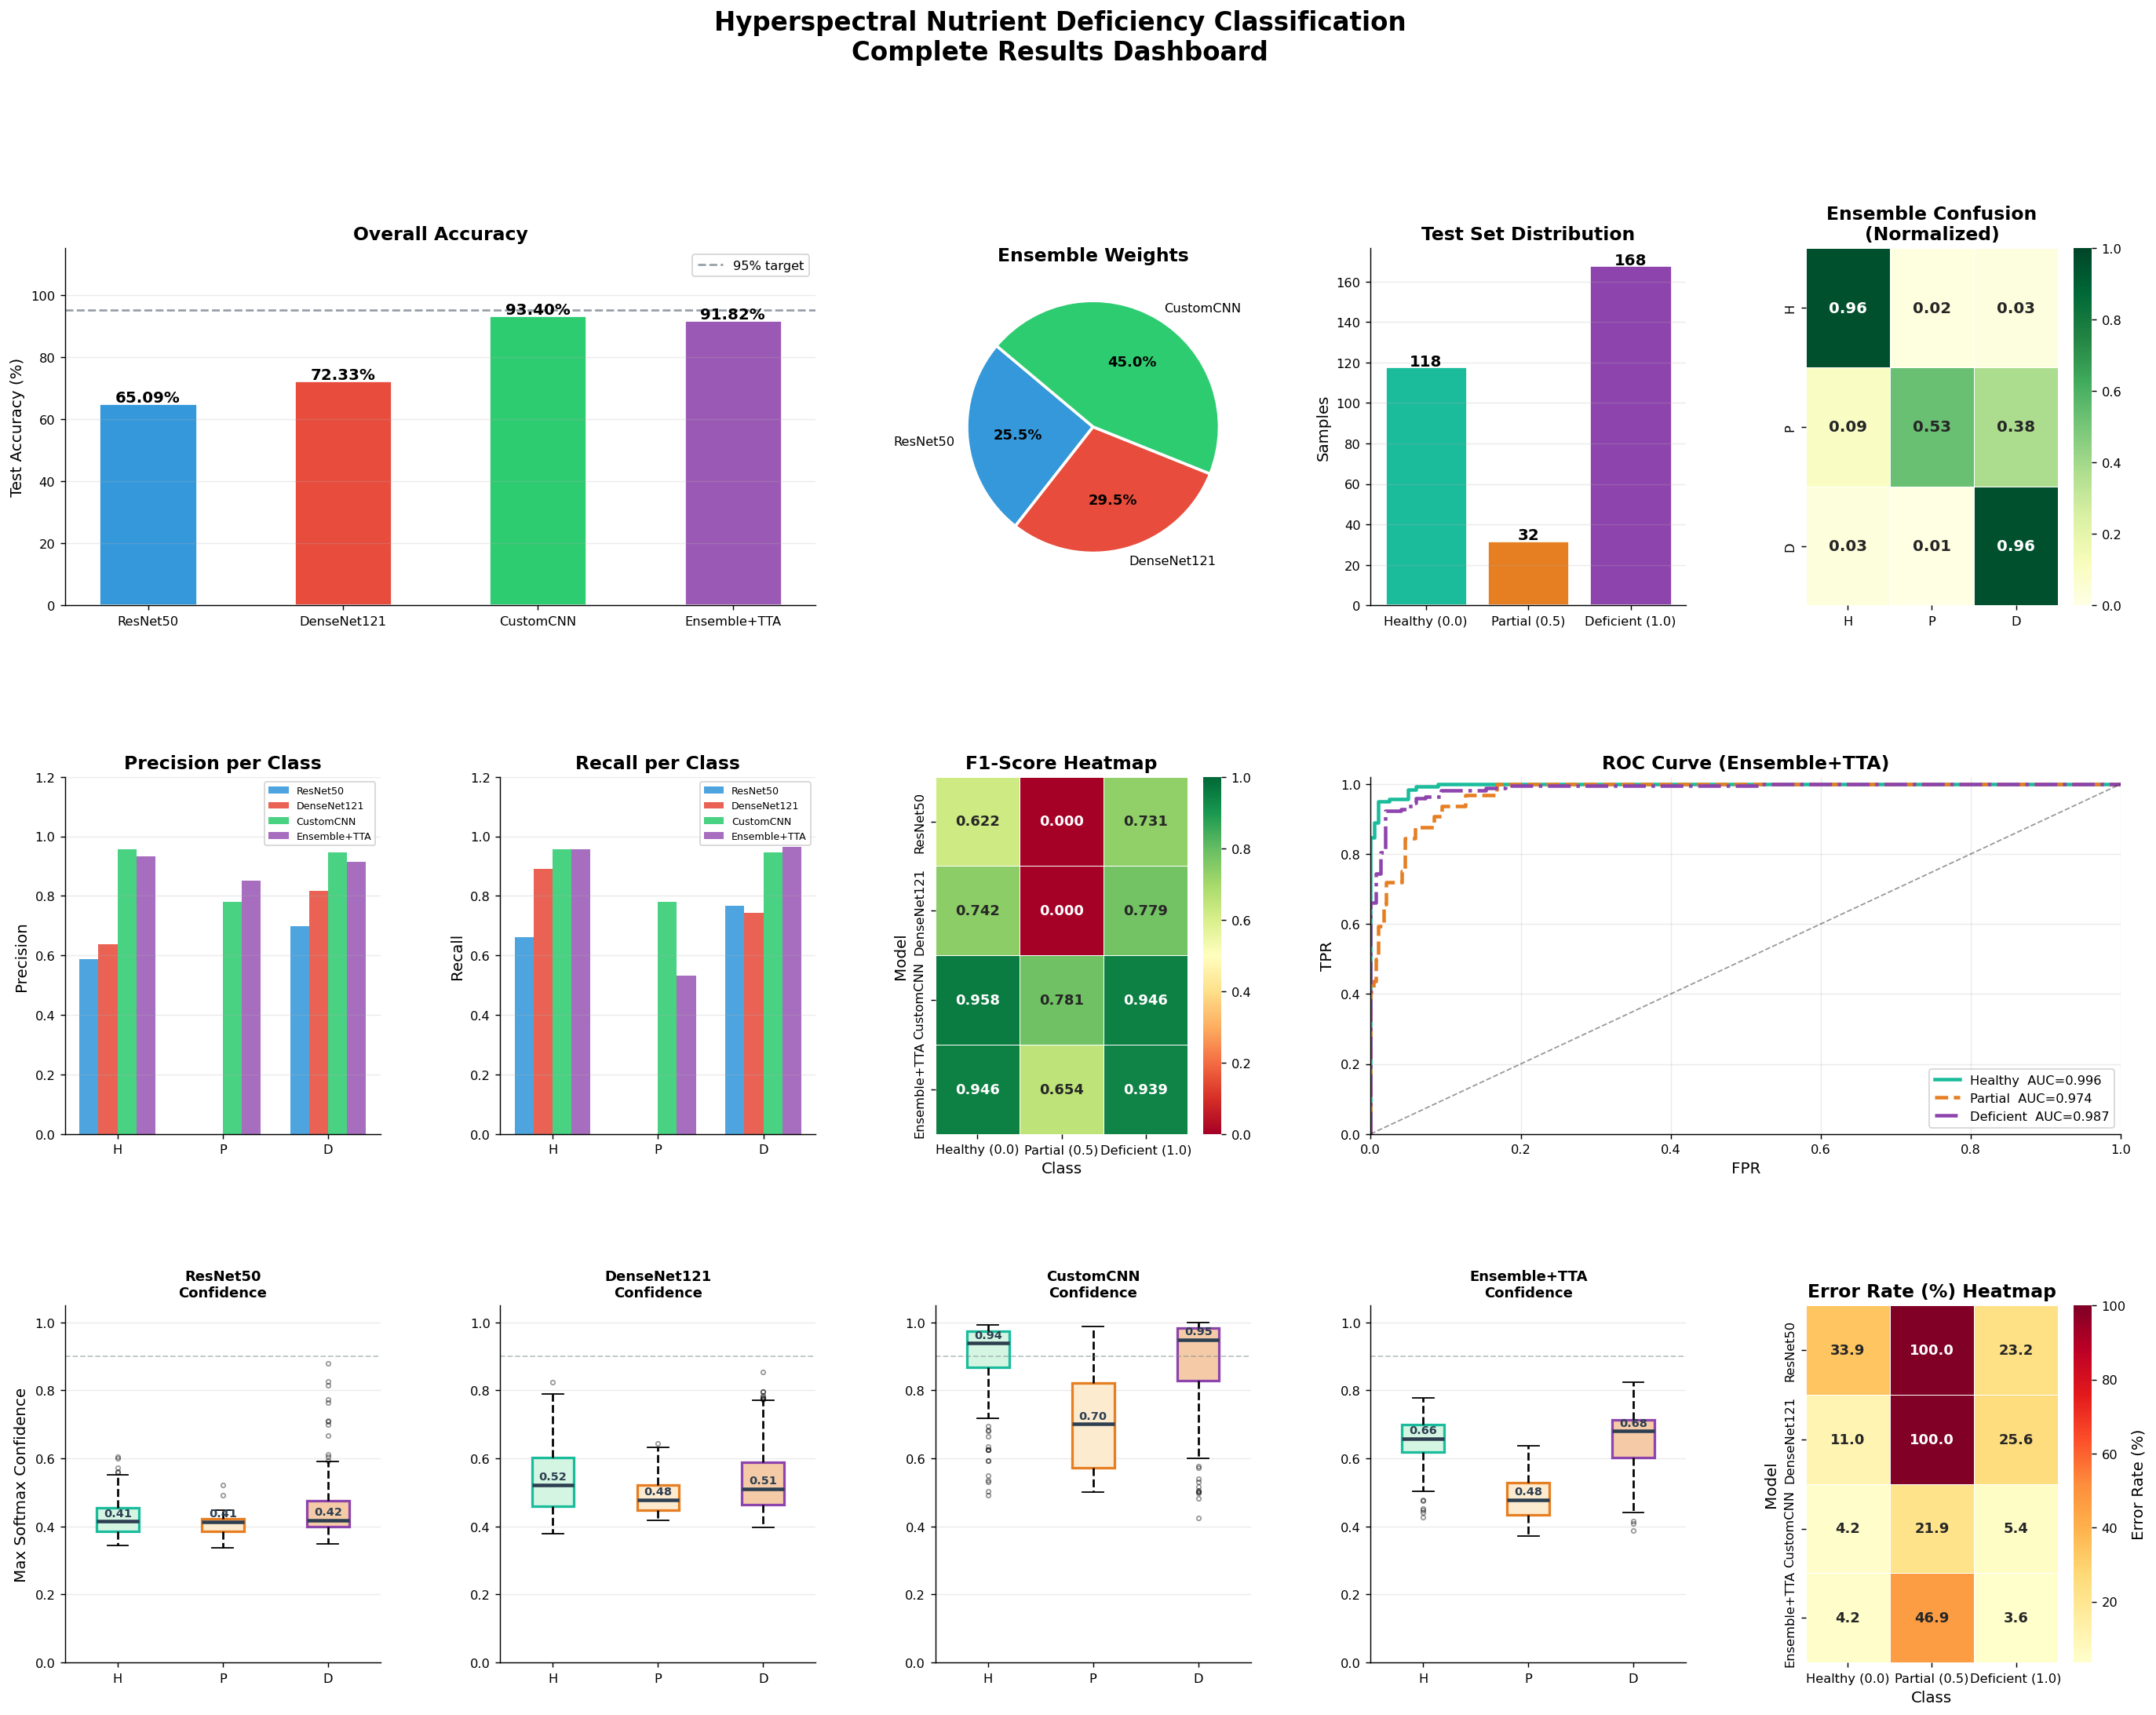

✅ Saved: viz10_FINAL_DASHBOARD.png  (Research paper ready!)


In [31]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION 10 — FINAL RESEARCH DASHBOARD
# (One figure with everything — paper ready)
# ═══════════════════════════════════════════════════════════

fig = plt.figure(figsize=(26, 18))
fig.suptitle(
    'Hyperspectral Nutrient Deficiency Classification\nComplete Results Dashboard',
    fontsize=18, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.48, wspace=0.38)

colors4 = list(MODEL_COLORS.values())
bc      = ['#d5f5e3', '#fdebd0', '#f5cba7']
be      = ['#1abc9c', '#e67e22', '#8e44ad']

# ═══ ROW 0 ═════════════════════════════════════════════════

# R0C0-1: Overall Accuracy Bar
ax_acc = fig.add_subplot(gs[0, :2])
bars_a = ax_acc.bar(all_model_names,
                    [metrics_dict[n]['Accuracy']*100 for n in all_model_names],
                    color=colors4, edgecolor='white', linewidth=1.5, width=0.5)
for bar, v in zip(bars_a, [metrics_dict[n]['Accuracy']*100 for n in all_model_names]):
    ax_acc.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax_acc.axhline(95, color='#2c3e50', ls='--', lw=1.5, alpha=0.5, label='95% target')
ax_acc.set_ylim(0, 115)
ax_acc.set_ylabel('Test Accuracy (%)')
ax_acc.set_title('Overall Accuracy', fontweight='bold')
ax_acc.legend(); ax_acc.grid(axis='y', alpha=0.25)

# R0C2: Ensemble weight pie
ax_pie = fig.add_subplot(gs[0, 2])
wedges, _, autotexts = ax_pie.pie(
    ens_weights, labels=model_names, colors=colors4[:3],
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
ax_pie.set_title('Ensemble Weights', fontweight='bold')

# R0C3: Test set class distribution
ax_dist = fig.add_subplot(gs[0, 3])
counts  = [np.sum(y_test_encoded == c) for c in range(len(hyper_class_names))]
bars_d  = ax_dist.bar(hyper_class_names, counts, color=CLASS_COLORS, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars_d, counts):
    ax_dist.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(v), ha='center', fontweight='bold', fontsize=11)
ax_dist.set_ylabel('Samples')
ax_dist.set_title('Test Set Distribution', fontweight='bold')
ax_dist.grid(axis='y', alpha=0.25)

# R0C4: Ensemble confusion (normalized)
ax_cm0 = fig.add_subplot(gs[0, 4])
cm0    = confusion_matrix(y_test_encoded, final_preds).astype(float)
cm0   /= cm0.sum(axis=1, keepdims=True)
sns.heatmap(cm0, annot=True, fmt='.2f', cmap='YlGn',
            xticklabels=['H','P','D'], yticklabels=['H','P','D'],
            ax=ax_cm0, vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            annot_kws={'size':11,'weight':'bold'})
ax_cm0.set_title('Ensemble Confusion\n(Normalized)', fontweight='bold')

# ═══ ROW 1 ═════════════════════════════════════════════════

# R1C0: Precision grouped bar
ax_pre = fig.add_subplot(gs[1, 0])
for i, (mname, color) in enumerate(zip(all_model_names, colors4)):
    offset = (i - len(all_model_names)/2 + 0.5) * 0.18
    b = ax_pre.bar(np.arange(len(hyper_class_names)) + offset,
                   metrics_dict[mname]['Precision'], 0.18,
                   label=mname, color=color, alpha=0.88)
ax_pre.set_xticks(range(len(hyper_class_names)))
ax_pre.set_xticklabels(['H','P','D'])
ax_pre.set_ylim(0, 1.2); ax_pre.set_ylabel('Precision')
ax_pre.set_title('Precision per Class', fontweight='bold')
ax_pre.legend(fontsize=7); ax_pre.grid(axis='y', alpha=0.25)

# R1C1: Recall grouped bar
ax_rec = fig.add_subplot(gs[1, 1])
for i, (mname, color) in enumerate(zip(all_model_names, colors4)):
    offset = (i - len(all_model_names)/2 + 0.5) * 0.18
    ax_rec.bar(np.arange(len(hyper_class_names)) + offset,
               metrics_dict[mname]['Recall'], 0.18,
               label=mname, color=color, alpha=0.88)
ax_rec.set_xticks(range(len(hyper_class_names)))
ax_rec.set_xticklabels(['H','P','D'])
ax_rec.set_ylim(0, 1.2); ax_rec.set_ylabel('Recall')
ax_rec.set_title('Recall per Class', fontweight='bold')
ax_rec.legend(fontsize=7); ax_rec.grid(axis='y', alpha=0.25)

# R1C2: F1 heatmap
ax_f1h = fig.add_subplot(gs[1, 2])
f1_df  = pd.DataFrame(
    {m: metrics_dict[m]['F1-Score'] for m in all_model_names},
    index=hyper_class_names
).T
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax_f1h,
            linewidths=0.5, linecolor='white',
            annot_kws={'size':10,'weight':'bold'})
ax_f1h.set_title('F1-Score Heatmap', fontweight='bold')
ax_f1h.set_ylabel('Model'); ax_f1h.set_xlabel('Class')

# R1C3-4: ROC for Ensemble
ax_roc = fig.add_subplot(gs[1, 3:])
ens_probs = all_probs_dict['Ensemble+TTA']
ls_list   = ['-', '--', '-.']
for c_idx, (c_name, c_color, ls) in enumerate(
        zip(hyper_class_names, CLASS_COLORS, ls_list)):
    fpr, tpr, _ = roc_curve(y_bin[:, c_idx], ens_probs[:, c_idx])
    roc_auc     = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=c_color, lw=2.5, ls=ls,
                label=f'{c_name.split(" ")[0]}  AUC={roc_auc:.3f}')
ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1.02)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC Curve (Ensemble+TTA)', fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=9); ax_roc.grid(alpha=0.25)

# ═══ ROW 2 ═════════════════════════════════════════════════

# R2C0-3: Box plots for all 4 models
probs_for_box = [
    ('ResNet50',    all_probs_dict['ResNet50']),
    ('DenseNet121', all_probs_dict['DenseNet121']),
    ('CustomCNN',   all_probs_dict['CustomCNN']),
    ('Ensemble+TTA',all_probs_dict['Ensemble+TTA']),
]
for col_b, (mname, probs) in enumerate(probs_for_box):
    ax_b = fig.add_subplot(gs[2, col_b])
    max_conf = np.max(probs, axis=1)
    data     = [max_conf[y_test_encoded == c] for c in range(len(hyper_class_names))]
    bp = ax_b.boxplot(data, patch_artist=True, widths=0.4,
                      medianprops=dict(color='#2c3e50', lw=2.5),
                      whiskerprops=dict(lw=1.5, ls='--'),
                      flierprops=dict(marker='o', ms=3, alpha=0.4))
    for patch, fc, ec in zip(bp['boxes'], bc, be):
        patch.set_facecolor(fc); patch.set_edgecolor(ec); patch.set_linewidth(1.8)
    for j, d in enumerate(data):
        ax_b.text(j+1, np.median(d)+0.015, f'{np.median(d):.2f}',
                  ha='center', fontsize=8, fontweight='bold', color='#2c3e50')
    ax_b.set_xticklabels(['H','P','D'])
    ax_b.set_title(f'{mname}\nConfidence', fontweight='bold', fontsize=10)
    ax_b.set_ylim(0, 1.05)
    ax_b.axhline(0.9, color='#7f8c8d', ls='--', lw=1, alpha=0.5)
    ax_b.grid(axis='y', alpha=0.25)
    if col_b == 0: ax_b.set_ylabel('Max Softmax Confidence')

# R2C4: Misclassification error rates
ax_er = fig.add_subplot(gs[2, 4])
err_df = pd.DataFrame(error_rates, index=hyper_class_names).T
sns.heatmap(err_df, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax_er, linewidths=0.5, linecolor='white',
            annot_kws={'size':10,'weight':'bold'},
            cbar_kws={'label':'Error Rate (%)'})
ax_er.set_title('Error Rate (%) Heatmap', fontweight='bold')
ax_er.set_ylabel('Model'); ax_er.set_xlabel('Class')

plt.savefig(f'{SAVE_DIR}viz10_FINAL_DASHBOARD.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅ Saved: viz10_FINAL_DASHBOARD.png  (Research paper ready!)')

In [32]:
# ═══════════════════════════════════════════════════════════
# SUMMARY — Print all saved files
# ═══════════════════════════════════════════════════════════

print('=' * 60)
print('   VISUALIZATION COMPLETE — All Files Saved')
print('=' * 60)

files = sorted(os.listdir(SAVE_DIR))
for fname in files:
    fpath = os.path.join(SAVE_DIR, fname)
    size  = os.path.getsize(fpath) // 1024
    print(f'  {fname:50s}  {size:4d} KB')

print()
print('Final Model Performance Summary:')
print('-' * 45)
summary_rows = []
for mname in all_model_names:
    m   = metrics_dict[mname]
    row = {
        'Model'    : mname,
        'Accuracy' : f"{m['Accuracy']*100:.2f}%",
        'Prec (H)' : f"{m['Precision'][0]:.3f}",
        'Prec (P)' : f"{m['Precision'][1]:.3f}",
        'Prec (D)' : f"{m['Precision'][2]:.3f}",
        'Rec (H)'  : f"{m['Recall'][0]:.3f}",
        'Rec (P)'  : f"{m['Recall'][1]:.3f}",
        'Rec (D)'  : f"{m['Recall'][2]:.3f}",
        'F1 (H)'   : f"{m['F1-Score'][0]:.3f}",
        'F1 (P)'   : f"{m['F1-Score'][1]:.3f}",
        'F1 (D)'   : f"{m['F1-Score'][2]:.3f}",
    }
    summary_rows.append(row)

import pandas as pd
summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())
summary_df.to_csv(f'{SAVE_DIR}metrics_summary.csv')
print(f'\n✅ metrics_summary.csv saved.')

   VISUALIZATION COMPLETE — All Files Saved
  viz10_FINAL_DASHBOARD.png                            472 KB
  viz2_accuracy_comparison.png                          86 KB
  viz3_precision_recall_f1.png                          80 KB
  viz4_confidence_boxplots.png                         234 KB
  viz5_ensemble_weights.png                            124 KB
  viz6_confusion_matrices.png                          192 KB
  viz7_per_class_accuracy_heatmap.png                   99 KB
  viz8_roc_curves.png                                  158 KB
  viz9_error_analysis.png                              189 KB

Final Model Performance Summary:
---------------------------------------------
             Accuracy Prec (H) Prec (P) Prec (D) Rec (H) Rec (P) Rec (D) F1 (H) F1 (P) F1 (D)
Model                                                                                        
ResNet50       65.09%    0.586    0.000    0.697   0.661   0.000   0.768  0.622  0.000  0.731
DenseNet121    72.33%    0.636    0.